In [ ]:
import json
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import powerlaw as pl
from scipy import stats
import scipy.stats as stats
import matplotlib.cm as cm
from typing import Tuple, List
from collections import Counter
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from collections import defaultdict
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import ColorbarBase
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize


#Here we set the style of the plots
plt.rc('text', usetex=True)
plt.rc('axes', labelsize=12)
plt.rc('axes', titlesize=12)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('legend', fontsize=12)
plt.rc('figure', titlesize=12)
plt.rc('font', family='serif')
matplotlib.rcParams['text.usetex'] = True

#Define the data and file paths
supplementary_data_path = "data_shared/supplementary_data/"
data_path = "data_shared/main_data/"
figures_path = "output/"

---

### **Figure S1: Weight Rescaling in the AFG**

In [2]:
#Here we load the monthly authors and the example flow for month 49
monthly_authors = pd.read_csv(supplementary_data_path + "unique_authors_month_49.tsv", names=["subreddit", "monthly_authors"])
example_flow_month_49 = pd.read_csv(supplementary_data_path + "example_flow_month_49.tsv", names=["subreddit_i", "subreddit_j", "weight", "arithmetic_rescaled_weight", "geometric_rescaled_weight"])

#We convert the monthly authors to integers
monthly_authors["monthly_authors"] = monthly_authors["monthly_authors"].astype(int)

#We compute the in-strength and out-strength of each subreddit
out_strengths = example_flow_month_49.groupby("subreddit_i").sum().drop("subreddit_j", axis=1)
in_strengths = example_flow_month_49.groupby("subreddit_j").sum().drop("subreddit_i", axis=1)
joined_example = out_strengths.join(in_strengths, how="inner", lsuffix="_out", rsuffix="_in")

#Here we sum the weights on each column
joined_example["total_weight"] = joined_example["weight_out"] + joined_example["weight_in"]
joined_example["total_arithmetic_rescaled_weight"] = joined_example["arithmetic_rescaled_weight_out"] + joined_example["arithmetic_rescaled_weight_in"]
joined_example["total_geometric_rescaled_weight"] = joined_example["geometric_rescaled_weight_out"] + joined_example["geometric_rescaled_weight_in"]

#Here we drop the previous columns
joined_example = joined_example.drop(["weight_out", "weight_in", "arithmetic_rescaled_weight_out", "arithmetic_rescaled_weight_in", "geometric_rescaled_weight_out", "geometric_rescaled_weight_in"], axis=1)

#Now we join the monthly authors
joined_monthly_authors = joined_example.join(monthly_authors.set_index("subreddit"), how="inner")


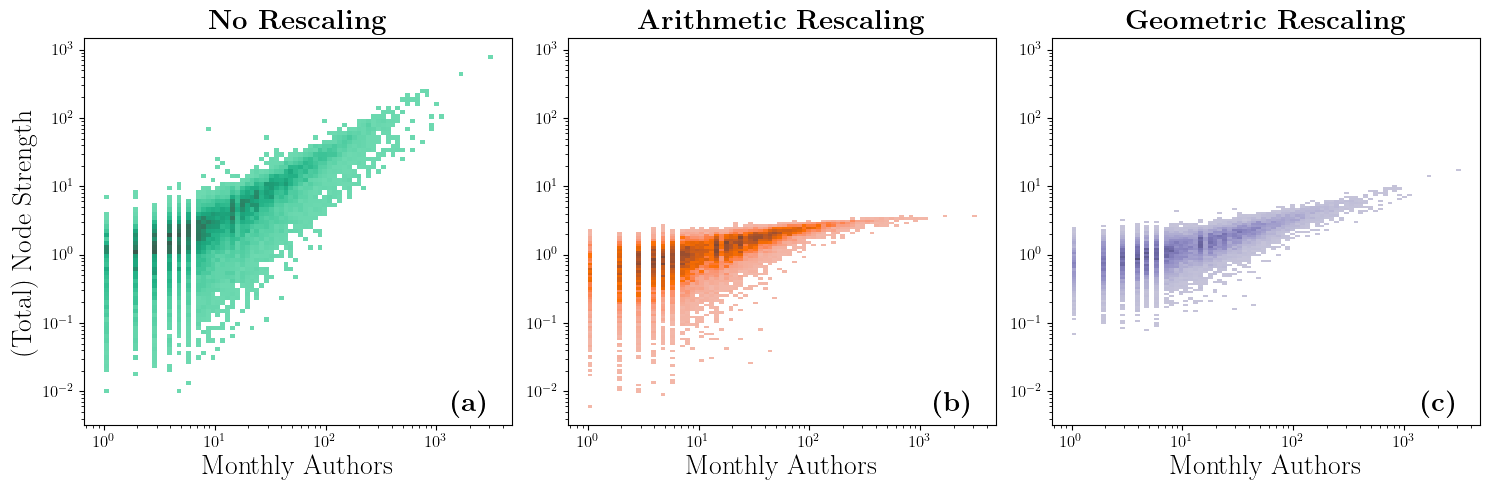

In [6]:
#Here we plot the three rescalings together
fig, ax = plt.subplots(1, 3, figsize=(15,5), sharey=True, sharex=True)
sns.histplot(data=joined_monthly_authors, x="monthly_authors", y="total_weight", bins=80, log_scale=[True, True], ax=ax[0], color="#1b9e77")
ax[0].set_xlabel("Monthly Authors", fontsize=20)
ax[0].set_ylabel(r"(Total) Node Strength", fontsize=20)
ax[0].set_title(r"\textbf{" +"No Rescaling" + r"}", fontsize=20)

sns.histplot(data=joined_monthly_authors, x="monthly_authors", y="total_arithmetic_rescaled_weight", bins=80, log_scale=[True, True], ax=ax[1], color="#d95f02")
ax[1].set_title(r"\textbf{" +"Arithmetic Rescaling" + r"}", fontsize=20)
ax[1].set_xlabel("Monthly Authors", fontsize=20)
ax[1].tick_params(labelleft=True)

sns.histplot(data=joined_monthly_authors, x="monthly_authors", y="total_geometric_rescaled_weight", bins=80, log_scale=[True, True], ax=ax[2], color="#7570b3")
ax[2].set_title(r"\textbf{" +"Geometric Rescaling" + r"}", fontsize=20)
ax[2].set_xlabel("Monthly Authors", fontsize=20)
ax[2].tick_params(labelleft=True)

#We add an a), b) and c) in bold in the bottom right corner of each plot
ax[0].text(0.95, 0.09, r"\textbf{(a)}", transform=ax[0].transAxes, fontsize=20, va='top', ha='right')
ax[1].text(0.95, 0.09, r"\textbf{(b)}", transform=ax[1].transAxes, fontsize=20, va='top', ha='right')
ax[2].text(0.95, 0.09, r"\textbf{(c)}", transform=ax[2].transAxes, fontsize=20, va='top', ha='right')
plt.tight_layout()
#plt.savefig(figures_path + "flow_rescaling.pdf", format="pdf", dpi=300)

----

### **Figure S2: AFG Weight Distribution and Community Size Distribution**



In [7]:
#Here we import the graphs (before and after filtering)
filtered_graph = pd.read_csv(supplementary_data_path + "filtered_attention_flow_graph_0.01_sampled.tsv", sep="\t", names=["subreddit_i", "subreddit_j", "weight"])
graph = pd.read_csv(supplementary_data_path + "attention_flow_graph_sampled.tsv", sep=",", names=["subreddit_i", "subreddit_j", "weight"])

In [ ]:
#First we obtain the in-degree and out-degree of each subreddit for the complete and filtered graphs
in_degree_complete = graph.groupby("subreddit_j").size().reset_index(name="in_degree")["in_degree"].values
out_degree_complete = graph.groupby("subreddit_i").size().reset_index(name="out_degree")["out_degree"].values
in_degree_filtered = filtered_graph.groupby("subreddit_j").size().reset_index(name="in_degree")["in_degree"].values
out_degree_filtered = filtered_graph.groupby("subreddit_i").size().reset_index(name="out_degree")["out_degree"].values

#Now we obtain the weights of the edges in the complete and filtered graphs
weights_complete = graph["weight"].values
weights_filtered = filtered_graph["weight"].values

#Now we fit a power-law distribution to the in-degree and out-degree of the complete and filtered graphs
#We also fit a log-normal distribution to the in-degree and out-degree of the complete and filtered graphs
fit_in_complete = pl.Fit(in_degree_complete)
fit_out_complete = pl.Fit(out_degree_complete)
fit_in_filtered = pl.Fit(in_degree_filtered)
fit_out_filtered = pl.Fit(out_degree_filtered)

#Here we fit a power-law distribution to the weights of the edges in the complete and filtered graphs
fit_weights_complete = pl.Fit(weights_complete, xmin=min(weights_complete))
fit_weights_filtered = pl.Fit(weights_filtered, xmin=min(weights_filtered))

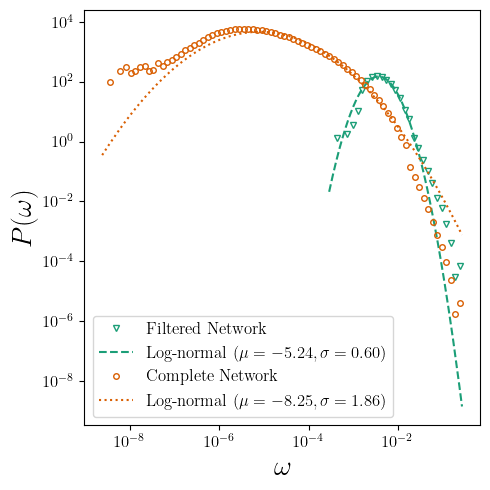

In [9]:
#Here we plot the degree and weight distributions for the complete and filtered graphs
fig, axs = plt.subplots(1, 1, figsize=(5, 5))

fig1 = fit_weights_filtered.plot_pdf(ax=axs, marker="v", linestyle="", label="Filtered Network", markersize=4, markeredgecolor="#1b9e77", fillstyle="none")
fit_weights_filtered.lognormal.plot_pdf(ax=fig1, linestyle="dashed", color="#1b9e77", label=f"Log-normal ($\\mu={fit_weights_filtered.lognormal.mu:.2f}, \\sigma={fit_weights_filtered.lognormal.sigma:.2f}$)")
fit_weights_complete.plot_pdf(ax=fig1, marker="o", linestyle="", label="Complete Network", markersize=4, markeredgecolor="#d95f02", fillstyle="none")
fit_weights_complete.lognormal.plot_pdf(ax=fig1, linestyle="dotted", color="#d95f02", label=f"Log-normal ($\\mu={fit_weights_complete.lognormal.mu:.2f}, \\sigma={fit_weights_complete.lognormal.sigma:.2f}$)")
axs.set_xscale("log")
axs.set_yscale("log")
axs.set_xlabel("$\\omega$", fontsize=20)
axs.set_ylabel("$P(\\omega)$", fontsize=20)
axs.legend(loc = "lower left", facecolor="white")
#axs.text(0.87, 0.95, r"\textbf{(a)}", transform=axs.transAxes, fontsize=20, va='top')

plt.tight_layout()
#plt.savefig(figures_path + "weights_distribution.pdf", format="pdf", dpi=300)

In [10]:
#First we load the community sizes
size_counts = list(json.loads(open(supplementary_data_path + "community_sizes.json").read()).values())
#Now we count the number of times a given size appears
size_counter = Counter(size_counts)

#Now we normalize the counts
total = sum(size_counter.values())
size_counter = {k: v/total for k, v in size_counter.items()}

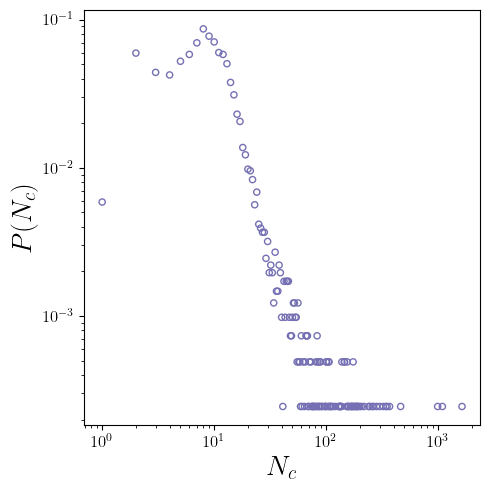

In [11]:
#Here we plot the distribution of the community sizes as a scatter plot in log-log scale
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.scatter(size_counter.keys(), size_counter.values(), marker="o", s=20, facecolors='none', edgecolors="#7570b3")
axs.set_xscale("log")
axs.set_yscale("log")
axs.set_xlabel("$N_c$", fontsize=20)
axs.set_ylabel("$P(N_c)$", fontsize=20)
#Here we save the plot
#axs.text(0.87, 0.95, r"\textbf{(b)}", transform=axs.transAxes, fontsize=20, va='top')

plt.tight_layout()
#plt.savefig(figures_path+"community_size_distribution.pdf", format="pdf", dpi=300)

----

### **Figure S3: Score distributions across social dimensions**

In [12]:
#Read the user demographic scores (anonymized)
user_demographic_scores_anonymized = pd.read_csv(data_path + "user_scores_general_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float})

#We get the subreddits of interest (those that appear in the filtered graph)
subreddits_interest = list(set(filtered_graph.subreddit_i).union(set(filtered_graph.subreddit_j)))

#Now we load the scores of subreddits (Waller and Anderson) and we filter them to keep only the subreddits of interest
demographic_scores = pd.read_csv(supplementary_data_path +"demographic_scores.csv")
#We just mantain the rows where the community is in the communities dictionary
demographic_scores = demographic_scores[demographic_scores["community"].isin(subreddits_interest)].reset_index(drop=True)
#We mantain only the columns we want
demographic_scores = demographic_scores[["community", "age","gender", "affluence", "partisan"]]
#We set the community column as the index
demographic_scores.set_index("community", inplace=True)

In [13]:
def calculate_bin_scores(scores_array: np.ndarray, bins:int=70) -> Tuple[np.ndarray, np.ndarray]:
    """
    Calculate histogram bins for a given array of scores.
    Parameters:
        scores_array (np.ndarray): Array of scores to calculate histogram bins for.
        bins (int): Number of bins to use for the histogram. Default is 70.
    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing the counts of scores in each bin and the corresponding bin centers.
    """
    # Compute z-scores
    mean = np.mean(scores_array)
    std = np.std(scores_array)
    z_scores = (scores_array - mean) / std

    # Histogram bins
    counts, bin_edges = np.histogram(z_scores, bins=bins)

    # Bin centers (for coloring)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    return counts, bin_centers

user_age_counts, user_age_bin_centers = calculate_bin_scores(user_demographic_scores_anonymized["age"].values)
demographic_age_counts, demographic_age_bin_centers = calculate_bin_scores(demographic_scores["age"].values)
user_gender_counts, user_gender_bin_centers = calculate_bin_scores(user_demographic_scores_anonymized["gender"].values)
demographic_gender_counts, demographic_gender_bin_centers = calculate_bin_scores(demographic_scores["gender"].values)
user_partisanship_counts, user_partisanship_bin_centers = calculate_bin_scores(user_demographic_scores_anonymized["partisanship"].values)
demographic_partisanship_counts, demographic_partisanship_bin_centers = calculate_bin_scores(demographic_scores["partisan"].values)
user_affluence_counts, user_affluence_bin_centers = calculate_bin_scores(user_demographic_scores_anonymized["affluence"].values)
demographic_affluence_counts, demographic_affluence_bin_centers = calculate_bin_scores(demographic_scores["affluence"].values)

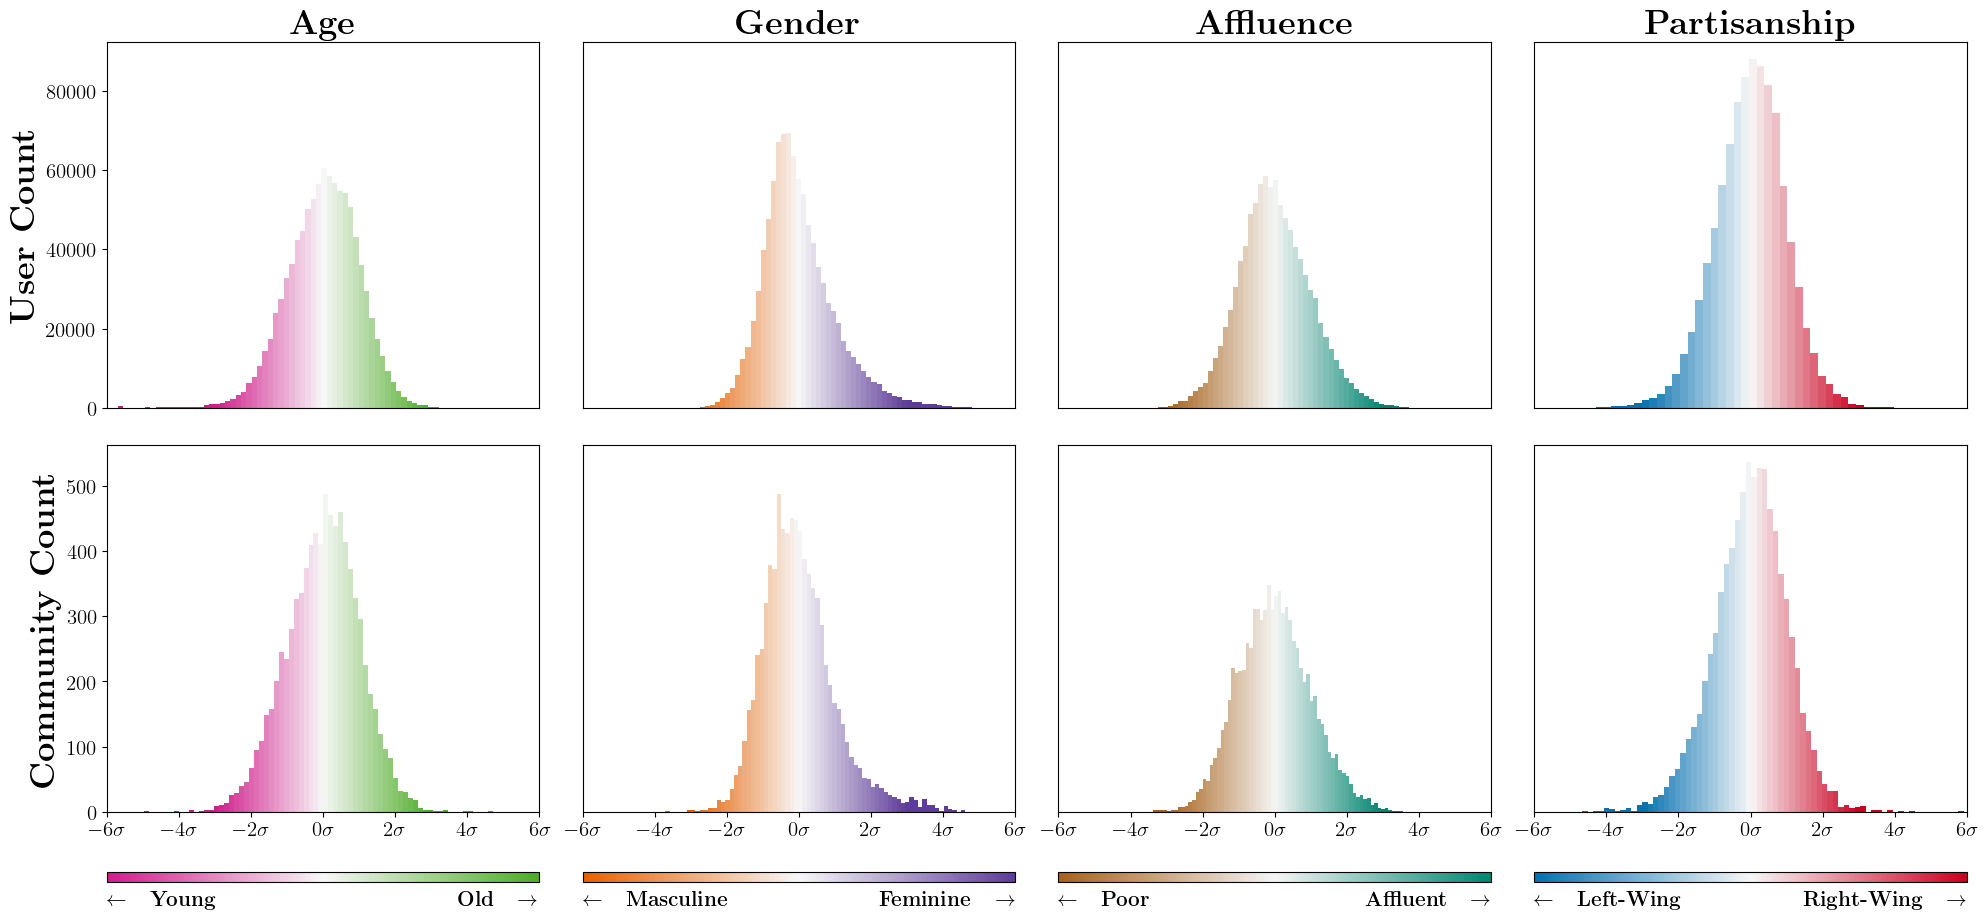

In [14]:
#We plot the distributions of the demographic scores for users and communities 

# Choose a custom colormap for each demographic category
cmap_funcs = [LinearSegmentedColormap.from_list("Age", ['#d01c8b', '#f7f7f7', '#4dac26']),
                LinearSegmentedColormap.from_list("Gender", ['#e66101','#f7f7f7', '#5e3c99']),
                LinearSegmentedColormap.from_list("Affluence", ['#a6611a', '#f5f5f5', '#018571']),
                LinearSegmentedColormap.from_list("Partisanship", ['#0571b0', '#f7f7f7','#ca0020'])]

#Normalize bin centers to [0,1] for colormap
norm = mcolors.Normalize(vmin=-3, vmax=3)

#Map bin centers to colors by demographic category
colors_user_age = cmap_funcs[0](norm(user_age_bin_centers))
colors_demographic_age = cmap_funcs[0](norm(demographic_age_bin_centers))
colors_user_gender = cmap_funcs[1](norm(user_gender_bin_centers))
colors_demographic_gender = cmap_funcs[1](norm(demographic_gender_bin_centers))
colors_user_affluence = cmap_funcs[2](norm(user_affluence_bin_centers))
colors_demographic_affluence = cmap_funcs[2](norm(demographic_affluence_bin_centers))
colors_user_partisanship = cmap_funcs[3](norm(user_partisanship_bin_centers))
colors_demographic_partisanship = cmap_funcs[3](norm(demographic_partisanship_bin_centers))

#Plot bars with the color corresponding to their z-score bin
fig, axs = plt.subplots(2, 4, figsize=(24, 10), sharex="col", sharey="row", gridspec_kw={'hspace': 0.1, 'wspace': 0.1})

# User Age
axs[0, 0].bar(user_age_bin_centers, user_age_counts, width=user_age_bin_centers[1] - user_age_bin_centers[0], color=colors_user_age)
axs[0, 0].set_title(r'\textbf{Age}', fontsize=25)
axs[0, 0].set_ylabel(r"\textbf{User Count}", fontsize=25)
axs[0, 0].set_xlim([-6, 6])

# Demographic Age
axs[1, 0].bar(demographic_age_bin_centers, demographic_age_counts, width=demographic_age_bin_centers[1] - demographic_age_bin_centers[0], color=colors_demographic_age)
axs[1, 0].set_ylabel(r"\textbf{Community Count}", fontsize=25)

# User Gender
axs[0, 1].bar(user_gender_bin_centers, user_gender_counts, width= user_gender_bin_centers[1] - user_gender_bin_centers[0], color=colors_user_gender)
axs[0, 1].set_title(r'\textbf{Gender}', fontsize=25)
axs[0, 1].set_xlim([-6, 6])

# Demographic Gender
axs[1, 1].bar(demographic_gender_bin_centers, demographic_gender_counts, width=demographic_gender_bin_centers[1] - demographic_gender_bin_centers[0], color=colors_demographic_gender)

# User Affluence
axs[0, 2].bar(user_affluence_bin_centers, user_affluence_counts, width=user_affluence_bin_centers[1] - user_affluence_bin_centers[0], color=colors_user_affluence)
axs[0, 2].set_title(r'\textbf{Affluence}', fontsize=25)
axs[0, 2].set_xlim([-6, 6])


# Demographic Affluence
axs[1, 2].bar(demographic_affluence_bin_centers, demographic_affluence_counts, width=demographic_affluence_bin_centers[1] - demographic_affluence_bin_centers[0], color=colors_demographic_affluence)

# User Partisanship
axs[0, 3].bar(user_partisanship_bin_centers, user_partisanship_counts, width=user_partisanship_bin_centers[1] - user_partisanship_bin_centers[0], color=colors_user_partisanship)
axs[0, 3].set_title(r'\textbf{Partisanship}', fontsize=25)
axs[0, 3].set_xlim([-6, 6])

# Demographic Partisanship
axs[1, 3].bar(demographic_partisanship_bin_centers, demographic_partisanship_counts, width=demographic_partisanship_bin_centers[1] - demographic_partisanship_bin_centers[0], color=colors_demographic_partisanship)

#For all the axes we set the fontsize of the tick labels to 15
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=15)

#We delete the x-axis tick lines for the first row
for ax in axs[0, :]:
    ax.tick_params(axis='x', which='both', bottom=False, top=False)

#We delete the y-axis tick lines for plots that are not the first column
axs[0,1].tick_params(axis='y', which='both', left=False, right=False)
axs[0,2].tick_params(axis='y', which='both', left=False, right=False)
axs[0,3].tick_params(axis='y', which='both', left=False, right=False)
axs[1,1].tick_params(axis='y', which='both', left=False, right=False)
axs[1,2].tick_params(axis='y', which='both', left=False, right=False)
axs[1,3].tick_params(axis='y', which='both', left=False, right=False)


#We add tick labels for the x-axis as $\sigma$-scores
for ax in axs[1, :]:
    ax.set_xticks([-6, -4, -2, 0, 2, 4, 6])
    ax.set_xticklabels([r"$-6\sigma$", r"$-4\sigma$", r"$-2\sigma$", r"$0\sigma$", r"$2\sigma$", r"$4\sigma$", r"$6\sigma$"])


cmaps_labels = [(r"$\mathbf{\leftarrow} \quad \textbf{Young}$", r"$\textbf{Old} \quad\mathbf{\rightarrow}$"),
    (r"$\mathbf{\leftarrow} \quad \textbf{Masculine}$", r"$\textbf{Feminine} \quad\mathbf{\rightarrow}$"),
                   (r"$\mathbf{\leftarrow} \quad \textbf{Poor}$", r"$\textbf{Affluent} \quad\mathbf{\rightarrow}$"),
                   (r"$\mathbf{\leftarrow} \quad \textbf{Left-Wing}$", r"$\textbf{Right-Wing} \quad\mathbf{\rightarrow}$")]

# Get figure and adjust colorbar size/position
fig = plt.gcf()

for col in range(4):
    # Position of the bottom subplot in this column
    ax_bottom = axs[1, col]

    # Get bbox in figure coords for the bottom axis
    bbox = ax_bottom.get_position()

    # Create a new axis below the bottom subplot for colorbar
    cax = fig.add_axes([bbox.x0, bbox.y0 - 0.07, bbox.width, 0.01])  # tweak vertical position & height here
    # Draw horizontal colorbar with the right colormap with a small width. The title should be at the bottom
    # and the ticks should be at the bottom
    ColorbarBase(cax, cmap=cmap_funcs[col], norm=norm, orientation='horizontal', ticklocation='bottom')

    # We change the tick labels to be the z-scores
    cax.set_xticks([])
    #The location is left and right (and the bottom)
    # Manually place the title text below the colorbar
    # Left-aligned title below the colorbar
    cax.text(0.0, -0.9,  # x = 0.0 (left), y = below axis
            r"\textbf{" + cmaps_labels[col][0] + "}",
            transform=cax.transAxes,
            fontsize=15,
            va='top',
            ha='left')

    # Right-aligned title below the colorbar
    cax.text(1.0, -0.9,  # x = 1.0 (right), y = below axis
            r"\textbf{" + cmaps_labels[col][1] + "}",
            transform=cax.transAxes,
            fontsize=15,
            va='top',
            ha='right')

#plt.savefig(figures_path + "demographic_scores_z_scores.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()


----

### **Figure S4: Projected vs self-declared age distribution.**

In [15]:
#Read the user demographic scores (anonymized)
user_demographic_scores_anonymized = pd.read_csv(data_path + "user_scores_general_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float})
#Read the labeled user demographic scores (anonymized)
user_demographic_scores_extended = pd.read_csv(supplementary_data_path + "user_scores_labeled_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence", "label"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float, "label": float})

In [16]:
def edges_from_centers(bin_centers: np.ndarray) -> np.ndarray:
    """
    Reconstruct bin edges from uniformly spaced bin centers.
    Parameters:
        bin_centers (np.ndarray): Array of bin centers.
    Returns:
        np.ndarray: Array of bin edges.
    """
    width = bin_centers[1] - bin_centers[0]
    return np.concatenate([bin_centers - width / 2, [bin_centers[-1] + width / 2]])


def median_age_per_bin(z_labeled: np.ndarray, labeled_ages: np.ndarray, bin_edges: np.ndarray, min_samples: int = 3) -> np.ndarray:
    """
    Median real age of labeled users in each bin.
    Bins with fewer than `min_samples` users get NaN (not plotted).
    Parameters:
        z_labeled (np.ndarray): Z-scores of labeled users.
        labeled_ages (np.ndarray): Real ages of labeled users.
        bin_edges (np.ndarray): Edges of the bins.
        min_samples (int): Minimum number of samples required to compute median. Default is 3.
    Returns:
        np.ndarray: Median ages for each bin, with NaN for bins with insufficient samples.
    """
    medians = np.full(len(bin_edges) - 1, np.nan)
    for i in range(len(bin_edges) - 1):
        in_bin = (z_labeled >= bin_edges[i]) & (z_labeled < bin_edges[i + 1])
        ages_in_bin = labeled_ages[in_bin]
        if len(ages_in_bin) >= min_samples:
            medians[i] = np.median(ages_in_bin)
    return medians

#Full population: predicted age scores only (no labels)
all_scores = user_demographic_scores_anonymized["age"].values
# Labeled subset: predicted scores + real ages
labeled_scores = user_demographic_scores_extended["age"].values
labeled_ages = user_demographic_scores_extended["label"].values

#Histogram of the full population (z-scored internally by the function)
counts, bin_centers = calculate_bin_scores(all_scores, bins=70)
bin_edges = edges_from_centers(bin_centers)
bin_width = bin_centers[1] - bin_centers[0]

#Standardize the labeled subset with the FULL population's mean/std, so it lives on the same z-score scale as the histogram
z_labeled = (labeled_scores - np.mean(all_scores)) / np.std(all_scores)

median_real_age = median_age_per_bin(z_labeled, labeled_ages, bin_edges)

/var/folders/jb/blc95kfn77qcc1pqkvjw7y_c0000gn/T/ipykernel_29935/2672400779.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


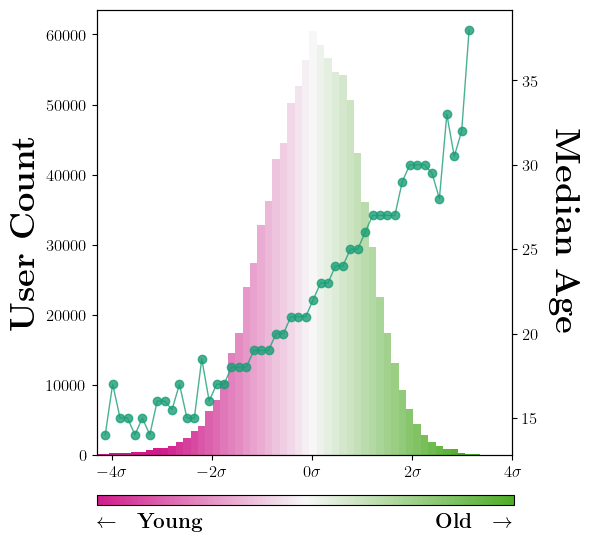

In [18]:
fig, ax1 = plt.subplots(figsize=(6, 5))
#We define the colormap of the instagram
cmap = LinearSegmentedColormap.from_list("Age", ['#d01c8b', '#f7f7f7', '#4dac26'])
norm = Normalize(vmin=-3, vmax=3)
colors = cmap(norm(bin_centers))

# Full population histogram, we cap the x axis to -3 to 3
ax1.bar(bin_centers,counts, width=(bin_edges[1] - bin_edges[0]), color=colors)
ax1.set_xlim(-4.3, 4)
ax1.set_ylabel(r"\textbf{User Count}", fontsize=25)

ax1.set_xticks([-4, -2, 0, 2, 4])
ax1.set_xticklabels([r"$-4\sigma$", r"$-2\sigma$", r"$0\sigma$", r"$2\sigma$", r"$4\sigma$"])

#We add a horizontal colorbar below the plot with the same colormap and normalization
#Get bbox in figure coords for the bottom axis
bbox = ax1.get_position()

# Create a new axis below the bottom subplot for colorbar
cax = fig.add_axes([bbox.x0 + 0.045, bbox.y0 - 0.13, bbox.width-0.08, 0.02])  # tweak vertical position & height here
# Draw horizontal colorbar with the right colormap with a small width. The title should be at the bottom
# and the ticks should be at the bottom
ColorbarBase(cax, cmap=cmap, norm=norm, orientation='horizontal', ticklocation='bottom')

# We change the tick labels to be the z-scores
cax.set_xticks([])
# Manually place the title text below the colorbar
# Left-aligned title below the colorbar
cax.text(0.0, -0.9,  # x = 0.0 (left), y = below axis
        r"$\mathbf{\leftarrow} \quad \textbf{Young}$",
        transform=cax.transAxes,
        fontsize=15,
        va='top',
        ha='left')

# Right-aligned title below the colorbar
cax.text(1.0, -0.9,  # x = 1.0 (right), y = below axis
        r"$\textbf{Old} \quad \mathbf{\rightarrow}$",
        transform=cax.transAxes,
        fontsize=15,
        va='top',
        ha='right')

# Median real age (labeled subset)
ax2 = ax1.twinx()
ax2.plot(bin_centers, median_real_age, marker="o", color='#1b9e77', alpha=0.8, linewidth=1, markersize=6)
ax2.set_ylabel(r"\textbf{Median Age}", fontsize=25, rotation=270, labelpad=30)

plt.tight_layout()
#plt.savefig(figures_path + "age_score_validation.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()


----

### **Figure 2A: Sociodemographic composition of community entrants and group overrepresentation**

In [19]:
def map_to_percentiles_smooth(values: np.ndarray, reference: np.ndarray) -> np.ndarray:
    """
    Map values to percentiles based on a reference distribution using a smooth approach.
    Parameters:
        values (np.ndarray): Array of values to map to percentiles.
        reference (np.ndarray): Reference array to compute percentiles against.
    Returns:
        np.ndarray: Array of percentile ranks corresponding to the input values.
    """
    combined = np.sort(reference)
    ranks = np.searchsorted(combined, values, side='right')
    percentile_ranks = ranks / len(combined) * 100
    return percentile_ranks

def quantile_density_grid(baselines: List[np.ndarray], comparisons_grid: List[List[np.ndarray]], y_labels: List[str], column_titles: List[str], bins: int, cmap_funcs: List[LinearSegmentedColormap], cmaps_labels: List[str]=None, save_as: str="quantile_density_grid_users.pdf"):
    """
    Create a grid of quantile density plots for baseline and comparison distributions.
    Parameters:
        baselines (List[np.ndarray]): List of baseline distributions for each column.
        comparisons_grid (List[List[np.ndarray]]): List of lists containing comparison distributions for each column.
        y_labels (List[str]): Labels for each row of the grid.
        column_titles (List[str]): Titles for each column of the grid.
        bins (int): Number of bins to use for the histograms.
        cmap_funcs (List[LinearSegmentedColormap]): List of colormap functions for each column.
        cmaps_labels (List[str], optional): Labels for the colormaps. Defaults to None.
        save_as (str, optional): Filename to save the figure. Defaults to "quantile_density_grid_users.pdf".
    """
    n_cols = len(column_titles)
    n_rows = len(y_labels)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.9 * n_cols, 1 * n_rows),
                             sharex="col", sharey="row",
                             gridspec_kw={'hspace': 0.0, 'wspace': 0.02},
                             constrained_layout=True)

    norm = Normalize(vmin=-3, vmax=3)

    for col in range(n_cols):
        baseline = np.asarray(baselines[col])
        baseline_percentiles = 100 * (rankdata(baseline, method='average') - 1) / (len(baseline) - 1)
        bin_edges = np.linspace(0, 100, bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        values_at_centers = np.percentile(baseline, bin_centers)
        z_scores = (values_at_centers - np.median(values_at_centers)) / np.std(values_at_centers)
        colors = cmap_funcs[col](norm(z_scores))

        # Density histogram
        baseline_counts, _ = np.histogram(baseline_percentiles, bins=bin_edges)
        comparison_counts_list = [
            np.histogram(map_to_percentiles_smooth(comp, baseline), bins=bin_edges)[0]
            for comp in comparisons_grid[col]
        ]

        def draw_filled(ax, counts):
            # Apply LOESS smoothing
            smoothed = lowess(counts, bin_centers, frac=0.2, return_sorted=True)
            x_smooth, y_smooth = smoothed[:, 0], smoothed[:, 1]

            # Interpolate the smoothed values at original bin centers (for matching colors)
            y_interp = np.interp(bin_centers, x_smooth, y_smooth)

            # Draw colored LOESS-smoothed segments
            for i in range(len(bin_centers) - 1):
                x0, x1 = bin_centers[i], bin_centers[i + 1]
                y0, y1 = y_interp[i], y_interp[i + 1]
                verts = [(x0, 0), (x0, y0), (x1, y1), (x1, 0)]
                ax.fill(*zip(*verts), color=colors[i], edgecolor=None, linewidth=0, antialiased=True)


        for row in range(n_rows):
            ax = axes[row][col] if n_cols > 1 else axes[row]
            if row == 0:
                draw_filled(ax, baseline_counts)
            else:
                draw_filled(ax, comparison_counts_list[row - 1])


            # Formatting
            ax.set_yticks([])
            #We remove the lines on the tick labels
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.set_xticks([])

            #Y-axis label for the leftmost column
            if col == 0:
                ax.set_ylabel(r"\textbf{" + y_labels[row] + "}", fontsize=12, rotation=0, labelpad=20, va='center', ha='right')

        # Bottom row: show x-axis ticks
        axes[-1][col].set_xticks([0, 50, 100])
        axes[-1][col].set_xticklabels([r"$0\%$", r"$50\%$", r"$100\%$"], fontsize=9)
        axes[-1][col].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
        axes[-1][col].set_xlim(0, 100)
        # Colorbar under the last columns of axes
        sm = cm.ScalarMappable(norm=norm, cmap=cmap_funcs[col])
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes[:, col], orientation='horizontal', pad=0.02, aspect=30)
        #We put two different titles for the colorbar: one to the left and one to the right (both on the top)
        cbar.ax.set_title(r"\textbf{" + cmaps_labels[col][0] + "}", fontsize=9, loc= 'left')
        cbar.ax.set_title(r"\textbf{" + cmaps_labels[col][1] + "}", fontsize=9, loc='right')
        #We set both titles to the top of the colorbar
        cbar.ax.xaxis.set_label_position('bottom')

        cbar.ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
        cbar.ax.set_xticklabels([r"$-3\sigma$", r"$-2\sigma$", r"$-\sigma$", r"$0$", r"$\sigma$", r"$2\sigma$", r"$3\sigma$"], fontsize=9)

    
        # Column titles
        axes[0][col].set_title(r"\textbf{" + column_titles[col] + "}", fontsize=18, pad=10)

    fig.canvas.draw()  # Ensure layout is finalized
    for col in range(n_cols):
        #  Compute x position of 50th percentile in figure coordinates
        x_disp = axes[0][col].transData.transform((50, 0))[0]
        fig_x = fig.transFigure.inverted().transform((x_disp, 0))[0]

        # Compute vertical span across all rows in this column
        bbox_top = axes[0][col].get_window_extent().transformed(fig.transFigure.inverted())
        bbox_bottom = axes[-1][col].get_window_extent().transformed(fig.transFigure.inverted())
        y_top = bbox_top.y1
        y_bottom = bbox_bottom.y0

        # Draw a vertical line in figure coordinates
        line = plt.Line2D(
            [fig_x, fig_x], [y_bottom, y_top],
            transform=fig.transFigure,
            color='black', linestyle='--', linewidth=1, clip_on=False
        )
        fig.add_artist(line)
    #plt.savefig(figures_path + save_as, format="pdf", dpi=300, bbox_inches='tight')
    plt.show()

In [20]:
#Read the user demographic scores (anonymized)
user_demographic_scores_anonymized = pd.read_csv(data_path + "user_scores_general_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float})

#Read all the anonymized dataframes
conservative_df = pd.read_csv(data_path + "user_scores_before_Conservative_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0)
conspiracy_df = pd.read_csv(data_path + "user_scores_before_conspiracy_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0)
socialism_df = pd.read_csv(data_path + "user_scores_before_socialism_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0)
environment_df = pd.read_csv(data_path + "user_scores_before_environment_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0)
esoterism_df = pd.read_csv(data_path + "user_scores_before_spirituality_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0)

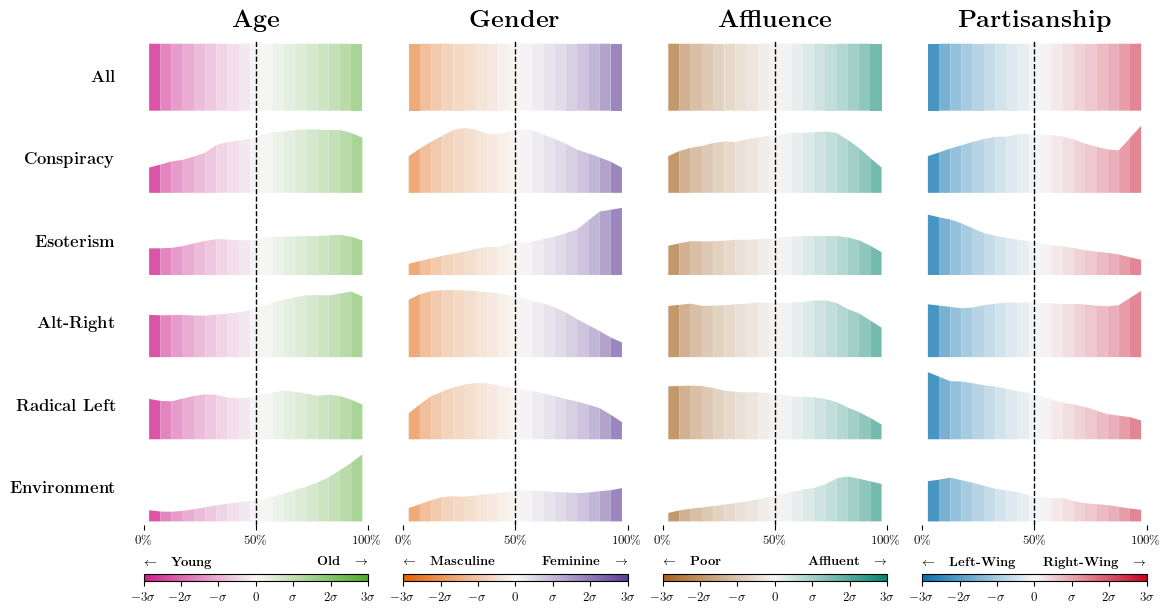

In [21]:
# Baselines for each column
baseline_age = user_demographic_scores_anonymized["age"].to_numpy()
baseline_gender = user_demographic_scores_anonymized["gender"].to_numpy()
baseline_affluence = user_demographic_scores_anonymized["affluence"].to_numpy()
baseline_partisan = user_demographic_scores_anonymized["partisanship"].to_numpy()

# Comparisons for each row under each column
comparisons_age = [
    conspiracy_df["age"].to_numpy(),
    esoterism_df["age"].to_numpy(),
    conservative_df["age"].to_numpy(),
    socialism_df["age"].to_numpy(),
    environment_df["age"].to_numpy(),
]

comparisons_gender = [
    conspiracy_df["gender"].to_numpy(),
    esoterism_df["gender"].to_numpy(),
    conservative_df["gender"].to_numpy(),
    socialism_df["gender"].to_numpy(),
    environment_df["gender"].to_numpy(),
]

comparisons_affluence = [
    conspiracy_df["affluence"].to_numpy(),
    esoterism_df["affluence"].to_numpy(),
    conservative_df["affluence"].to_numpy(),
    socialism_df["affluence"].to_numpy(),
    environment_df["affluence"].to_numpy(),
]
comparisons_partisan = [
    conspiracy_df["partisanship"].to_numpy(),
    esoterism_df["partisanship"].to_numpy(),
    conservative_df["partisanship"].to_numpy(),
    socialism_df["partisanship"].to_numpy(),
    environment_df["partisanship"].to_numpy(),
]


# Labels
row_labels = ['All', 'Conspiracy', 'Esoterism', 'Alt-Right', 'Radical Left', 'Environment']
column_titles = ['Age', 'Gender', 'Affluence', 'Partisanship']
cmap_funcs = [LinearSegmentedColormap.from_list("Age", ['#d01c8b', '#f7f7f7', '#4dac26']),
                LinearSegmentedColormap.from_list("Gender", ['#e66101','#f7f7f7', '#5e3c99']),
                LinearSegmentedColormap.from_list("Affluence", ['#a6611a', '#f5f5f5', '#018571']),
                LinearSegmentedColormap.from_list("Partisanship", ['#0571b0', '#f7f7f7','#ca0020'])]

# Call the function 
quantile_density_grid(
    baselines=[baseline_age, baseline_gender, baseline_affluence, baseline_partisan],
    comparisons_grid=[comparisons_age, comparisons_gender, comparisons_affluence, comparisons_partisan],
    y_labels=row_labels,
    column_titles=column_titles,
    bins=20,
    cmap_funcs=cmap_funcs,
    cmaps_labels=[(r"$\mathbf{\leftarrow} \quad \textbf{Young}$", r"$\textbf{Old} \quad\mathbf{\rightarrow}$"),
    (r"$\mathbf{\leftarrow} \quad \textbf{Masculine}$", r"$\textbf{Feminine} \quad\mathbf{\rightarrow}$"),
                   (r"$\mathbf{\leftarrow} \quad \textbf{Poor}$", r"$\textbf{Affluent} \quad\mathbf{\rightarrow}$"),
                   (r"$\mathbf{\leftarrow}\quad\textbf{Left-Wing}$", r"$\textbf{Right-Wing}\quad \mathbf{\rightarrow}$")]

)


----

### **Figure 2B: Sociodemographic composition of community entrants and group overrepresentation**

In [22]:
def compute_log_likelihood_ratios_multi(baselines: List[np.ndarray], comparisons_list: List[List[np.ndarray]], bins: int = 4, eps: float = 1e-9):
    """
    Compute log-likelihood ratios for multiple groups of comparisons against their respective baselines.
    Parameters:
        baselines (List[np.ndarray]): List of baseline distributions for each group.
        comparisons_list (List[List[np.ndarray]]): List of lists containing comparison distributions for each group.
        bins (int): Number of bins to use for the histograms. Default is 4.
        eps (float): Small value to avoid division by zero. Default is 1e-9.
    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing the log-likelihood ratio matrix and the likelihood ratio matrix without log transformation.
    """

    m = len(baselines)
    n = len(comparisons_list[0])
    bin_edges = np.linspace(0, 100, bins + 1)
    
    llr_matrix = np.zeros((n, m))
    lr_matrix = np.zeros((n, m))  # Likelihood ratios without log transformation

    for j in range(m):  # For each baseline and its list of comparisons
        baseline = baselines[j]
        comparisons = comparisons_list[j]

        for i in range(n):
            comp = comparisons[i]
            comp_percentiles = map_to_percentiles_smooth(comp, baseline)
            comp_counts, _ = np.histogram(comp_percentiles, bins=bin_edges)
            comp_probs = (comp_counts + eps) / ((comp_counts.sum() + eps) * bins)
            # Example: log-likelihood ratio of low vs high percentiles
            lr = comp_probs[-1] / comp_probs[0]
            llr = np.log2(lr)
            llr_matrix[i, j] = llr
            lr_matrix[i, j] = lr

    return llr_matrix, lr_matrix

# Baselines for each column
baseline_age = user_demographic_scores_anonymized["age"].to_numpy()
baseline_gender = user_demographic_scores_anonymized["gender"].to_numpy()
baseline_affluence = user_demographic_scores_anonymized["affluence"].to_numpy()
baseline_partisan = user_demographic_scores_anonymized["partisanship"].to_numpy()

baselines = [baseline_age, baseline_gender, baseline_affluence, baseline_partisan]
comparisons_list = [
    [conspiracy_df["age"].to_numpy(), esoterism_df["age"].to_numpy(), conservative_df["age"].to_numpy(), socialism_df["age"].to_numpy(), environment_df["age"].to_numpy()],
    [conspiracy_df["gender"].to_numpy(), esoterism_df["gender"].to_numpy(), conservative_df["gender"].to_numpy(), socialism_df["gender"].to_numpy(), environment_df["gender"].to_numpy()],
    [conspiracy_df["affluence"].to_numpy(), esoterism_df["affluence"].to_numpy(), conservative_df["affluence"].to_numpy(), socialism_df["affluence"].to_numpy(), environment_df["affluence"].to_numpy()],
    [conspiracy_df["partisanship"].to_numpy(), esoterism_df["partisanship"].to_numpy(), conservative_df["partisanship"].to_numpy(), socialism_df["partisanship"].to_numpy(), environment_df["partisanship"].to_numpy()],
]

llr_matrix_, lr_matrix_ = compute_log_likelihood_ratios_multi(baselines, comparisons_list, eps=0)


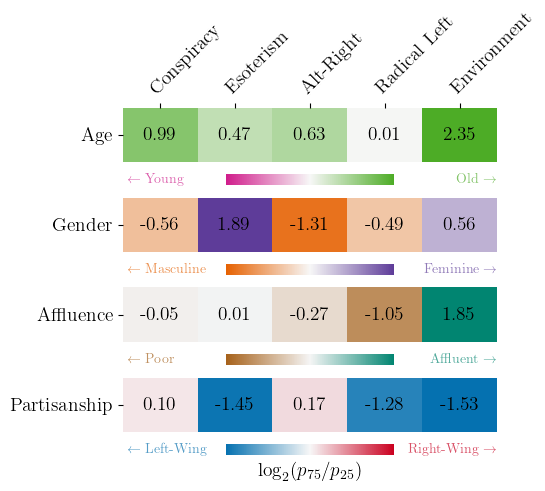

In [23]:
#Real matrix
llr_matrix = llr_matrix_.T
lr_matrix = lr_matrix_.T

#Define custom colormaps for each row
colormaps = [
    LinearSegmentedColormap.from_list("Age", ['#d01c8b', '#f7f7f7', '#4dac26']),
                LinearSegmentedColormap.from_list("Gender", ['#e66101','#f7f7f7', '#5e3c99']),
                LinearSegmentedColormap.from_list("Affluence", ['#a6611a', '#f5f5f5', '#018571']),
                LinearSegmentedColormap.from_list("Partisanship", ['#0571b0', '#f7f7f7','#ca0020'])
]
#Normalize: center at 0
norm = TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=1.5)

row_labels = ["Age", "Gender", "Affluence", "Partisanship"]
col_labels = ["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"]
cmaps_labels=[(r"$\leftarrow$ Young", r"Old $\rightarrow$"),
    (r"$\leftarrow$ Masculine", r"Feminine $\rightarrow$"),
                   (r"$\leftarrow$ Poor", r"Affluent $\rightarrow$"),
                   (r"$\leftarrow$ Left-Wing", r"Right-Wing $\rightarrow$")]

n_rows, n_cols = llr_matrix.shape

fig, ax = plt.subplots(figsize=(5.5, 5))

llr_matrix = llr_matrix[::-1]  # Reverse the rows
lr_matrix = lr_matrix[::-1]  # Reverse the rows for likelihood ratios
row_labels = row_labels[::-1]  # Reverse the labels
colormaps = colormaps[::-1]    # Reverse the colormaps
cmaps_labels = cmaps_labels[::-1]  # Reverse the labels for colormaps


#Plot each row with its custom colormap
for i in range(n_rows):
    data = llr_matrix[i:i+1, :]
    
    # Plot the row
    img = ax.imshow(data, extent=(0, n_cols, i+0.4, i+1),
                    cmap=colormaps[i], norm=norm,
                    aspect='auto', interpolation='none')

    # Colorbar below each row
    cax = inset_axes(ax, width="45%", height="3%", loc='lower center',
                     bbox_to_anchor=(0, +0.036 + i * 0.25, 1, 1),
                     bbox_transform=ax.transAxes, borderpad=0)
    cbar = plt.colorbar(img, cax=cax, orientation='horizontal')
    cbar.ax.set_xticks([])
    cbar.outline.set_visible(False)

    if i == 0:
        cbar.set_label(r"$\log_2 (p_{75}/p_{25})$", fontsize=14, labelpad=5)

    left_label, right_label = cmaps_labels[i]
    ax.text(0.05, +0.195 + i * 1, left_label, va='center', ha='left', fontsize=10, color=colormaps[i](norm(-1)))
    ax.text(5.0, +0.195 + i * 1, right_label, va='center', ha='right', fontsize=10, color=colormaps[i](norm(1)))


# Annotate heatmap values
for i in range(n_rows):
    for j in range(n_cols):
        ax.text(j + 0.5, i + 0.7, f"{llr_matrix[i, j]:.2f}",
                ha='center', va='center', color='black', fontsize=14)

# Tick positions: only center of each column
ax.set_xticks(np.arange(0.5, n_cols, 1))
ax.set_xticklabels(col_labels, rotation=45, ha='left', rotation_mode="anchor", fontsize=14)
ax.set_yticks(np.arange(0.7, n_rows, 1))
ax.set_yticklabels(row_labels, fontsize=14)

# Axis setup
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.invert_yaxis()
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)

# Remove white grid lines between blocks
ax.set_xticks([], minor=True)
ax.set_yticks([], minor=True)
ax.grid(False)

# Remove all spines and padding
for spine in ax.spines.values():
    spine.set_visible(False)

#We add a y label to the right side of the plot
fig.subplots_adjust(
    left=0.24,   # space for y labels
    right=0.92,
    top=0.8,    # space for top x labels
    bottom=0.08
)
#plt.savefig(figures_path + "log_likelihood_ratios_heatmap_log2.pdf", format="pdf", dpi=300)
plt.show()


----

### **Figure S5: User score distributions across seed subreddits**

In [24]:
#Read the user demographic scores (anonymized)
user_demographic_scores_anonymized = pd.read_csv(data_path + "user_scores_general_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float}) 
#Read the demographic scores before the subreddit r_Conservative (anonymized)
scores_r_Conservative = pd.read_csv(supplementary_data_path + "user_scores_before_r_Conservative_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float})
#Read the demographic scores before the subreddit r_democrats (anonymized)
scores_r_democrats = pd.read_csv(supplementary_data_path + "user_scores_before_r_democrats_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float})
#Read the demographic scores before the subreddit r_AskMen (anonymized)
scores_r_AskMen = pd.read_csv(supplementary_data_path + "user_scores_before_r_AskMen_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float})
#Read the demographic scores before the subreddit r_AskWomen (anonymized)
scores_r_AskWomen = pd.read_csv(supplementary_data_path + "user_scores_before_r_AskWomen_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float})
#Read the demographic scores before the subreddit r_teenagers (anonymized)
scores_r_teenagers = pd.read_csv(supplementary_data_path + "user_scores_before_r_teenagers_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float})
#Read the demographic scores before the subreddit r_RedditForGrownups (anonymized)
scores_r_RedditForGrownups = pd.read_csv(supplementary_data_path + "user_scores_before_r_RedditForGrownups_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float})
#Read the demographic scores before the subreddit r_vagabond (anonymized)
scores_r_vagabond = pd.read_csv(supplementary_data_path + "user_scores_before_r_vagabond_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float})
#Read the demographic scores before the subreddit r_backpacking (anonymized)
scores_r_backpacking = pd.read_csv(supplementary_data_path + "user_scores_before_r_backpacking_filtered_5_anonymized.csv", sep=",", names=["age", "gender", "partisanship", "affluence"], header=0, dtype={"age": float, "gender": float, "partisanship": float, "affluence": float})

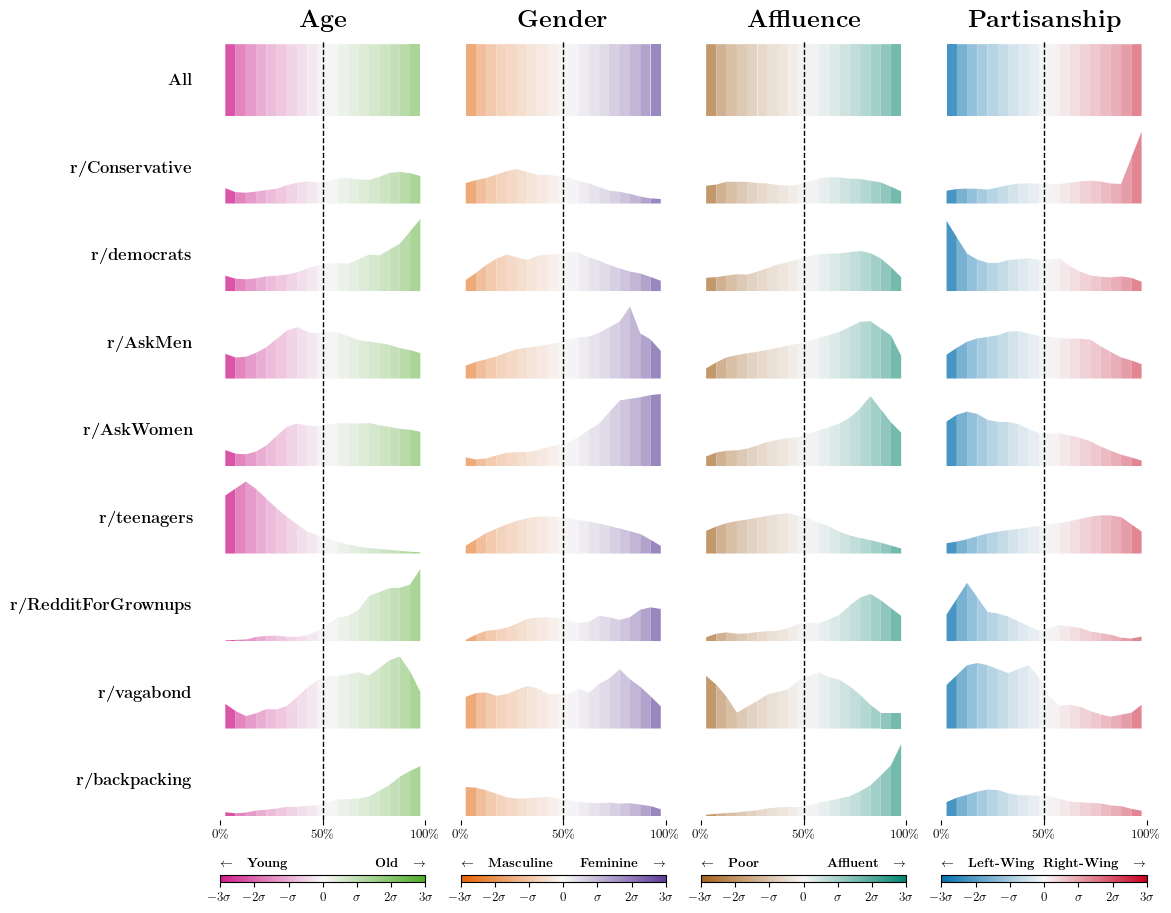

In [25]:
# Baselines for each column
baseline_age = user_demographic_scores_anonymized["age"].to_numpy()
baseline_gender = user_demographic_scores_anonymized["gender"].to_numpy()
baseline_affluence = user_demographic_scores_anonymized["affluence"].to_numpy()
baseline_partisan = user_demographic_scores_anonymized["partisanship"].to_numpy()

# Comparisons for each row under each column
comparisons_age = [
    scores_r_Conservative["age"].to_numpy(),
    scores_r_democrats["age"].to_numpy(),
    scores_r_AskMen["age"].to_numpy(),
    scores_r_AskWomen["age"].to_numpy(),
    scores_r_teenagers["age"].to_numpy(),
    scores_r_RedditForGrownups["age"].to_numpy(),
    scores_r_vagabond["age"].to_numpy(),
    scores_r_backpacking["age"].to_numpy(),
]

comparisons_gender = [
    scores_r_Conservative["gender"].to_numpy(),
    scores_r_democrats["gender"].to_numpy(),
    scores_r_AskMen["gender"].to_numpy(),
    scores_r_AskWomen["gender"].to_numpy(),
    scores_r_teenagers["gender"].to_numpy(),
    scores_r_RedditForGrownups["gender"].to_numpy(),
    scores_r_vagabond["gender"].to_numpy(),
    scores_r_backpacking["gender"].to_numpy(),
]

comparisons_affluence = [
    scores_r_Conservative["affluence"].to_numpy(),
    scores_r_democrats["affluence"].to_numpy(),
    scores_r_AskMen["affluence"].to_numpy(),
    scores_r_AskWomen["affluence"].to_numpy(),
    scores_r_teenagers["affluence"].to_numpy(),
    scores_r_RedditForGrownups["affluence"].to_numpy(),
    scores_r_vagabond["affluence"].to_numpy(),
    scores_r_backpacking["affluence"].to_numpy(),
]
comparisons_partisan = [
    scores_r_Conservative["partisanship"].to_numpy(),
    scores_r_democrats["partisanship"].to_numpy(),
    scores_r_AskMen["partisanship"].to_numpy(),
    scores_r_AskWomen["partisanship"].to_numpy(),
    scores_r_teenagers["partisanship"].to_numpy(),
    scores_r_RedditForGrownups["partisanship"].to_numpy(),
    scores_r_vagabond["partisanship"].to_numpy(),
    scores_r_backpacking["partisanship"].to_numpy(),
]


# Labels
row_labels = ['All', 'r/Conservative', 'r/democrats', 'r/AskMen', 'r/AskWomen', 'r/teenagers', 'r/RedditForGrownups', 'r/vagabond', 'r/backpacking']
column_titles = ['Age', 'Gender', 'Affluence', 'Partisanship']
cmap_funcs = [LinearSegmentedColormap.from_list("Age", ['#d01c8b', '#f7f7f7', '#4dac26']),
                LinearSegmentedColormap.from_list("Gender", ['#e66101','#f7f7f7', '#5e3c99']),
                LinearSegmentedColormap.from_list("Affluence", ['#a6611a', '#f5f5f5', '#018571']),
                LinearSegmentedColormap.from_list("Partisanship", ['#0571b0', '#f7f7f7','#ca0020'])]

# Call the function 
quantile_density_grid(
    baselines=[baseline_age, baseline_gender, baseline_affluence, baseline_partisan],
    comparisons_grid=[comparisons_age, comparisons_gender, comparisons_affluence, comparisons_partisan],
    y_labels=row_labels,
    column_titles=column_titles,
    bins=20,
    cmap_funcs=cmap_funcs,
    cmaps_labels=[(r"$\mathbf{\leftarrow} \quad \textbf{Young}$", r"$\textbf{Old} \quad\mathbf{\rightarrow}$"),
    (r"$\mathbf{\leftarrow} \quad \textbf{Masculine}$", r"$\textbf{Feminine} \quad\mathbf{\rightarrow}$"),
                   (r"$\mathbf{\leftarrow} \quad \textbf{Poor}$", r"$\textbf{Affluent} \quad\mathbf{\rightarrow}$"),
                   (r"$\mathbf{\leftarrow} \quad \textbf{Left-Wing}$", r"$\textbf{Right-Wing} \quad\mathbf{\rightarrow}$")],
    save_as="quantile_density_grid_reddit.pdf"

)


----

### **Figure S6: Cross-community reachability in stratified AFG**

In [26]:
#Upload the gateway data
gateway_info = json.load(open(data_path + 'gateways_bridges_results_full_inverted_final.json'))

#We convert the list of lists
communities = ["conspiracy","spirituality","Conservative","socialism", "environment"]

def get_reachability_matrices(gateway_info: dict, communities: List[str], key: str)-> Tuple[np.ndarray, np.ndarray]:
    """
    Get the reachability matrices for positive and negative reachability between communities.

    Parameters:
        gateway_info (dict): The gateway information containing reachability data.
        communities (List[str]): List of community names.
        key (str): The key for the demographic axis (e.g., "age", "gender", "affluence", "partisan").

    Returns:
        Tuple[np.ndarray, np.ndarray]: Two matrices representing positive and negative reachability between communities.
    """
    n = len(communities)
    results_positive = np.zeros((n, n))
    results_negative = np.zeros((n, n))

    for i, community in enumerate(communities):
        for j, community2 in enumerate(communities):
            if community == community2:
                results_positive[i, j] = np.nan
                results_negative[i, j] = np.nan
            else:
                results_positive[i, j] = dict(gateway_info[community][key]["positive"]["reachability"]).get(community2, np.nan)
                results_negative[i, j] = dict(gateway_info[community][key]["negative"]["reachability"]).get(community2, np.nan)

    return results_positive, results_negative

#We create for each axis: age, gender, affluence and partisan
results_age_positive, results_age_negative = get_reachability_matrices(gateway_info, communities, "age")
results_gender_positive, results_gender_negative = get_reachability_matrices(gateway_info, communities, "gender")
results_affluence_positive, results_affluence_negative = get_reachability_matrices(gateway_info, communities, "affluence")
results_partisan_positive, results_partisan_negative = get_reachability_matrices(gateway_info, communities, "partisan")


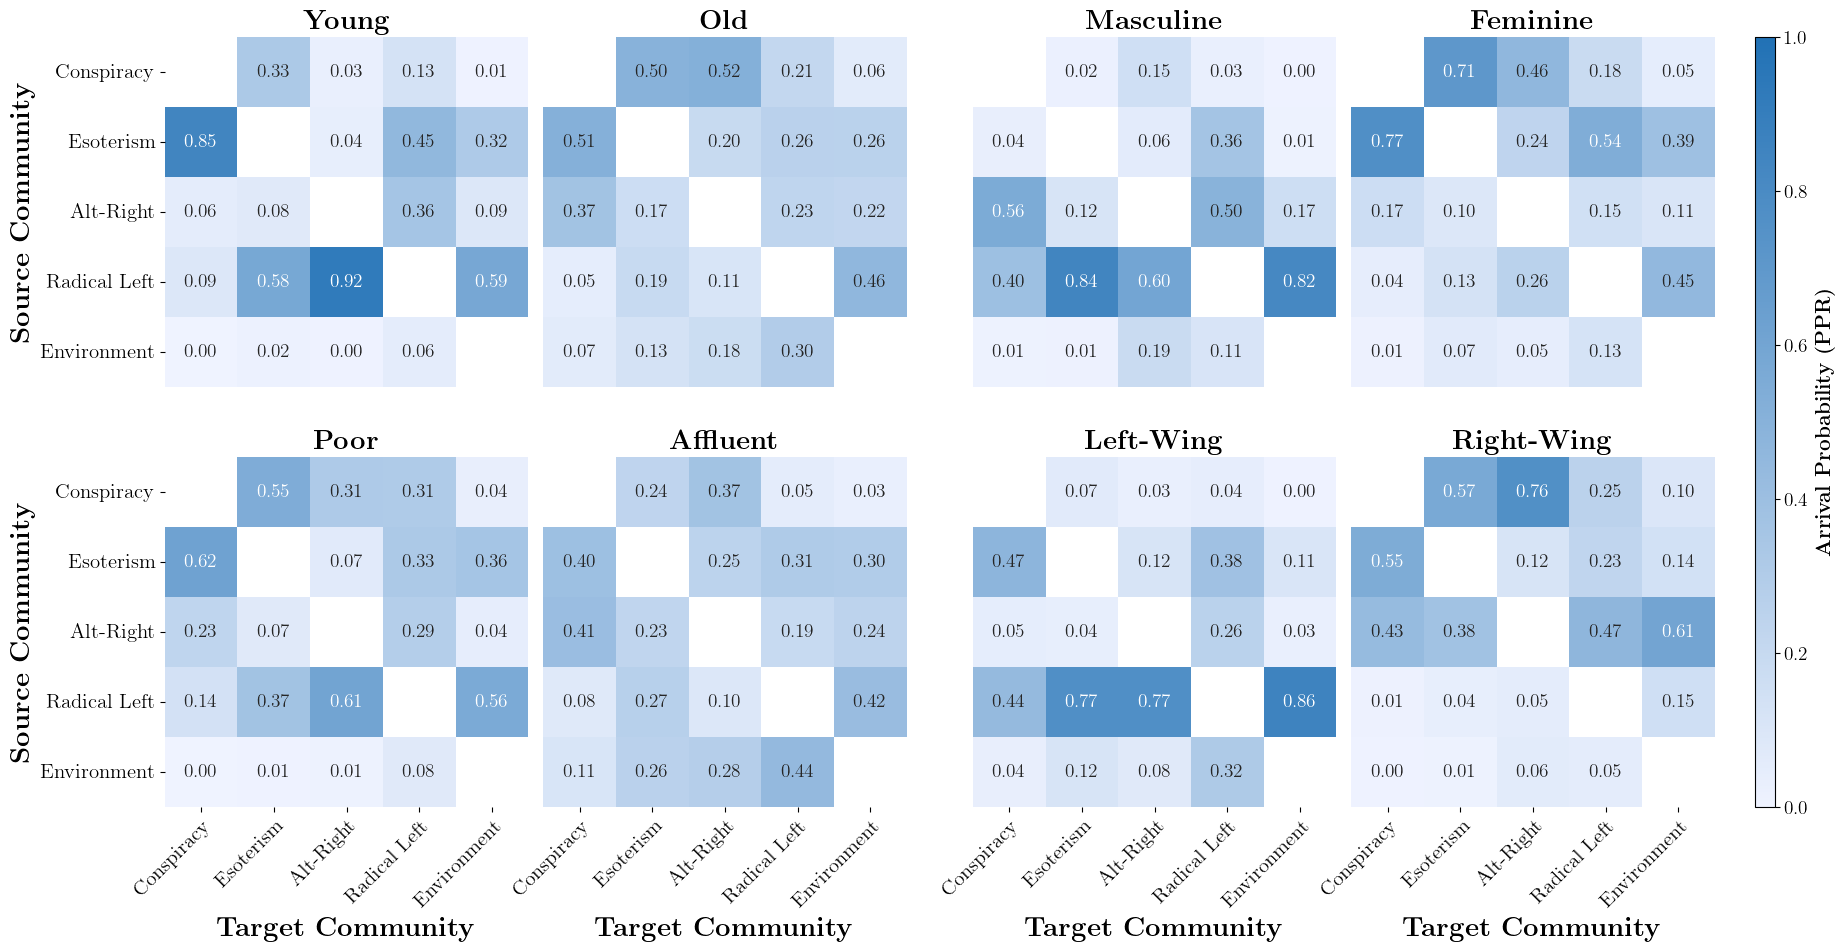

In [27]:
# Custom colormap
custom_cmap = LinearSegmentedColormap.from_list("custom_blues", ["#eff3ff", "#2171b5"])

# Set up figure and GridSpec with extra space between cols 1 and 2
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 5, width_ratios=[1, 1, 0.1, 1, 1], wspace=0.05)

# Create axes with shared x and y
axs = np.empty((2, 4), dtype=object)
axs[0, 0] = plt.subplot(gs[0, 0])
axs[1, 0] = plt.subplot(gs[1, 0], sharex=axs[0, 0], sharey=axs[0, 0])
axs[0, 1] = plt.subplot(gs[0, 1], sharex=axs[0, 0], sharey=axs[0, 0])
axs[1, 1] = plt.subplot(gs[1, 1], sharex=axs[0, 0], sharey=axs[0, 0])
axs[0, 2] = plt.subplot(gs[0, 3], sharex=axs[0, 0], sharey=axs[0, 0])
axs[1, 2] = plt.subplot(gs[1, 3], sharex=axs[0, 0], sharey=axs[0, 0])
axs[0, 3] = plt.subplot(gs[0, 4], sharex=axs[0, 0], sharey=axs[0, 0])
axs[1, 3] = plt.subplot(gs[1, 4], sharex=axs[0, 0], sharey=axs[0, 0])

# Plot heatmaps
sns.heatmap(results_age_negative.T, cmap=custom_cmap, annot=True, fmt=".2f", ax=axs[0, 0], cbar=False, vmin=0, vmax=1, annot_kws={"fontsize": 14})
sns.heatmap(results_age_positive.T, cmap=custom_cmap, annot=True, fmt=".2f", ax=axs[0, 1], cbar=False, vmin=0, vmax=1, annot_kws={"fontsize": 14})
sns.heatmap(results_gender_negative.T, cmap=custom_cmap, annot=True, fmt=".2f", ax=axs[0, 2], cbar=False, vmin=0, vmax=1, annot_kws={"fontsize": 14})
sns.heatmap(results_gender_positive.T, cmap=custom_cmap, annot=True, fmt=".2f", ax=axs[0, 3], cbar=False, vmin=0, vmax=1, annot_kws={"fontsize": 14})
sns.heatmap(results_affluence_negative.T, cmap=custom_cmap, annot=True, fmt=".2f", ax=axs[1, 0], cbar=False, vmin=0, vmax=1, annot_kws={"fontsize": 14})
sns.heatmap(results_affluence_positive.T, cmap=custom_cmap, annot=True, fmt=".2f", ax=axs[1, 1], cbar=False, vmin=0, vmax=1, annot_kws={"fontsize": 14})
sns.heatmap(results_partisan_negative.T, cmap=custom_cmap, annot=True, fmt=".2f", ax=axs[1, 2], cbar=False, vmin=0, vmax=1, annot_kws={"fontsize": 14})
sns.heatmap(results_partisan_positive.T, cmap=custom_cmap, annot=True, fmt=".2f", ax=axs[1, 3], cbar=False, vmin=0, vmax=1, annot_kws={"fontsize": 14})

# Set ticks and labels
yticks = [0.5, 1.5, 2.5, 3.5, 4.5]
yticklabels = ["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"]
xticks = [0.5, 1.5, 2.5, 3.5, 4.5]
xticklabels = ["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"]

axs[0, 0].set_yticks(yticks)
axs[0, 0].set_yticklabels(yticklabels, rotation=0, fontsize=15)
axs[1, 0].set_yticks(yticks)
axs[1, 0].set_yticklabels(yticklabels, rotation=0, fontsize=15)
axs[0, 0].set_ylabel(r"\textbf{Source Community}", fontsize=20)
axs[1, 0].set_ylabel(r"\textbf{Source Community}", fontsize=20)
axs[1, 0].set_xlabel(r"\textbf{Target Community}", fontsize=20)
axs[1, 1].set_xlabel(r"\textbf{Target Community}", fontsize=20)
axs[1, 2].set_xlabel(r"\textbf{Target Community}", fontsize=20)
axs[1, 3].set_xlabel(r"\textbf{Target Community}", fontsize=20)

# Apply x-tick labels only to bottom row, and y-tick labels only to leftmost column
for row in range(2):
    for col in range(4):
        ax = axs[row, col]

        # x-tick setup
        if row == 1:
            ax.set_xticks(xticks)
            ax.set_xticklabels(xticklabels, rotation=45, fontsize=15, ha="right", rotation_mode="anchor")
        else:
            ax.tick_params(axis="x", labelbottom=False, length=0)

        # y-tick setup
        if col == 0:
            continue  # already set above
        else:
            ax.tick_params(axis="y", labelleft=False, length=0)

# Titles
titles = [
    [r"\textbf{Young}", r"\textbf{Old}", r"\textbf{Masculine}", r"\textbf{Feminine}"],
    [r"\textbf{Poor}", r"\textbf{Affluent}", r"\textbf{Left-Wing}", r"\textbf{Right-Wing}"]
]
for row in range(2):
    for col in range(4):
        axs[row, col].set_title(titles[row][col], fontsize=20)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.11, 0.01, 0.77])# [left, bottom, width, height] in figure coordinates
cbar =fig.colorbar(axs[0, 0].collections[0], cax=cbar_ax)
cbar.set_label(r"\textbf{Arrival Probability (PPR)}", fontsize=15)  # Label font size
cbar.ax.tick_params(labelsize=14)   # Tick number font size
#plt.savefig(figures_path + "reachability_plot_col_stochastic.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

----

### **Figure 3: Cross-community transition probabilities by sociodemographic group**

In [29]:
def generate_sankey_dict(gateway_info:dict, dem_ax:str, filter_threshold:float=0.4)->defaultdict:
    """
    Generate a dictionary for Sankey diagram plotting based on reachability data.

    Parameters:
        gateway_info (dict): The gateway information containing reachability data.
        dem_ax (str): The demographic axis to consider (e.g., "age", "gender", "affluence", "partisan").
        filter_threshold (float): The threshold for filtering reachability weights. Default is 0.4.

    Returns:
        defaultdict: A dictionary where keys are tuples of (target, source) and values are lists of (condition, weight) tuples.
    """
    source_communities = ["conspiracy","spirituality","Conservative","socialism", "environment"]
    real_names = {"conspiracy": "Conspiracy",
                  "spirituality": "Esoterism",
                  "Conservative": "Alt-Right",
                  "socialism": "Radical Left",
                  "environment": "Environment"}
    #We create an empty defaultdict with list as default factory
    sankey_data = defaultdict(list)
    for source in source_communities:
        for pole in ["positive", "negative"]:
            reachability_dict = dict(gateway_info[source][dem_ax][pole]["reachability"])
            for target, weight in reachability_dict.items():
                condition = f"{dem_ax}_{pole}" if weight >= filter_threshold else "mask"
                sankey_data[(real_names[target], real_names[source])].append((condition, weight))

    return sankey_data

def coloring_function(src:str, tgt:str, condition:str)->str:
    """
    Determine the color for a given source-target pair based on the condition.

    Parameters:
        src (str): The source community.
        tgt (str): The target community.
        condition (str): The condition indicating the type of reachability.

    Returns:
        str: The color code corresponding to the condition.
    """
    if condition == "age_positive":
        return "#4dac26"
    elif condition == "age_negative":
        return "#d01c8b"
    elif condition == "gender_positive":
        return "#5e3c99"
    elif condition == "gender_negative":
        return "#e66101"
    elif condition == "affluence_positive":
        return "#018571"
    elif condition == "affluence_negative":
        return "#a6611a"
    elif condition == "partisan_positive":
        return "#ca0020"
    elif condition == "partisan_negative":
        return "#0571b0"
    elif condition == "mask":
        return "lightgray"
    
def sankey_v6(left, right, leftWeight=None, rightWeight=None, colorDict=None,
              leftLabels=None, rightLabels=None, aspect=4, rightColor=False,
              fontsize=14, figureName=None, closePlot=False,
              flowColorFunc=None, flowConditions=None, ax=None,
              highlightRight=None, fadedAlpha=0.08):
    """
    Sankey Diagram with:
      - node & flow colors
      - multiple condition sub-flows per (source, target)
      - explicit top-to-bottom label order
      - optional ax for subplot integration
      - highlightRight → label OR list of right labels to keep opaque

    Adapted from the Sankey package.
    """

    # --- Normalize highlightRight to a set ---
    if highlightRight is None:
        highlight_set = None
    elif isinstance(highlightRight, (list, tuple, set)):
        highlight_set = set(highlightRight)
    else:
        highlight_set = {highlightRight}

    # --- Setup ---
    if leftWeight is None:
        leftWeight = []
    if rightWeight is None:
        rightWeight = []
    if leftLabels is None:
        leftLabels = []
    if rightLabels is None:
        rightLabels = []

    if len(leftWeight) == 0:
        leftWeight = np.ones(len(left))
    if len(rightWeight) == 0:
        rightWeight = leftWeight

    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    # --- DataFrame prep ---
    if isinstance(left, pd.Series):
        left = left.reset_index(drop=True)
    if isinstance(right, pd.Series):
        right = right.reset_index(drop=True)
    df = pd.DataFrame({
        'left': left, 'right': right,
        'leftWeight': leftWeight, 'rightWeight': rightWeight
    })

    if df.isnull().any().any():
        raise ValueError("Sankey graph does not support null values.")

    allLabels = pd.Series(np.r_[df.left.unique(), df.right.unique()]).unique()
    if len(leftLabels) == 0:
        leftLabels = list(df.left.unique())
    if len(rightLabels) == 0:
        rightLabels = list(df.right.unique())

    # --- Colors ---
    if colorDict is None:
        colorDict = {}
        palette = sns.color_palette("hls", len(allLabels))
        for i, label in enumerate(allLabels):
            colorDict[label] = palette[i]

    # --- Flow weights per pair ---
    ns_l, ns_r = defaultdict(), defaultdict()
    for l in leftLabels:
        ld, rd = {}, {}
        for r in rightLabels:
            ld[r] = df[(df.left == l) & (df.right == r)].leftWeight.sum()
            rd[r] = df[(df.left == l) & (df.right == r)].rightWeight.sum()
        ns_l[l], ns_r[l] = ld, rd

    # --- Node positions ---
    total_left = df.leftWeight.sum()
    total_right = df.rightWeight.sum()
    spacing = 0.02 * max(total_left, total_right)

    leftWidths, rightWidths = defaultdict(), defaultdict()
    bottom = 0
    for l in leftLabels:
        val = df[df.left == l].leftWeight.sum()
        leftWidths[l] = {'left': val, 'bottom': bottom, 'top': bottom + val}
        bottom = leftWidths[l]['top'] + spacing

    bottom = 0
    for r in rightLabels:
        val = df[df.right == r].rightWeight.sum()
        rightWidths[r] = {'right': val, 'bottom': bottom, 'top': bottom + val}
        bottom = rightWidths[r]['top'] + spacing

    topEdge = max(bottom, spacing)
    xMax = topEdge / aspect

    # --- Draw left nodes ---
    for l in leftLabels:
        if highlight_set is not None:
            connected = any(ns_l[l].get(hr, 0) > 0 for hr in highlight_set)
            alpha_val = 0.99 if connected else fadedAlpha
        else:
            alpha_val = 0.99

        ax.fill_between(
            [-0.02 * xMax, 0],
            2 * [leftWidths[l]['bottom']],
            2 * [leftWidths[l]['top']],
            color=colorDict[l], alpha=alpha_val
        )
        ax.text(
            -0.05 * xMax,
            (leftWidths[l]['bottom'] + leftWidths[l]['top']) / 2,
            l, ha='right', va='center',
            fontsize=fontsize, alpha=alpha_val
        )

    # --- Draw right nodes ---
    for r in rightLabels:
        if highlight_set is not None:
            alpha_val = 0.99 if r in highlight_set else fadedAlpha
        else:
            alpha_val = 0.99

        ax.fill_between(
            [xMax, 1.02 * xMax],
            2 * [rightWidths[r]['bottom']],
            2 * [rightWidths[r]['top']],
            color=colorDict[r], alpha=alpha_val
        )
        ax.text(
            1.05 * xMax,
            (rightWidths[r]['bottom'] + rightWidths[r]['top']) / 2,
            r, ha='left', va='center',
            fontsize=fontsize, alpha=0.99
        )

    # --- Draw flows ---
    for l in leftLabels:
        for r in rightLabels:
            total_flow = ns_l[l][r]
            if total_flow == 0:
                continue

            cond_weights = (flowConditions.get((l, r))
                            if flowConditions and (l, r) in flowConditions
                            else [(None, total_flow)])

            for cond, cond_w in cond_weights:
                ys_d = np.array(50 * [leftWidths[l]['bottom']] +
                                50 * [rightWidths[r]['bottom']])
                ys_d = np.convolve(ys_d, 0.05 * np.ones(20), mode='valid')
                ys_d = np.convolve(ys_d, 0.05 * np.ones(20), mode='valid')

                ys_u = np.array(50 * [leftWidths[l]['bottom'] + cond_w] +
                                50 * [rightWidths[r]['bottom'] + cond_w])
                ys_u = np.convolve(ys_u, 0.05 * np.ones(20), mode='valid')
                ys_u = np.convolve(ys_u, 0.05 * np.ones(20), mode='valid')

                color = (
                    flowColorFunc(l, r, cond)
                    if flowColorFunc else
                    (colorDict[r] if rightColor else colorDict[l])
                )

                if highlight_set is not None:
                    alpha_val = 0.65 if r in highlight_set else fadedAlpha
                else:
                    alpha_val = 0.65

                ax.fill_between(
                    np.linspace(0, xMax, len(ys_d)), ys_d, ys_u,
                    alpha=alpha_val, color=color
                )

                leftWidths[l]['bottom'] += cond_w
                rightWidths[r]['bottom'] += cond_w

    ax.axis('off')
    return ax

def get_sankey_lists(sankey_data:dict)->Tuple[list, list, list]:
    """
    Convert the sankey_data dictionary into three lists: left nodes, right nodes, and weights.

    Parameters:
        sankey_data (dict): A dictionary where keys are tuples of (target, source) and values are lists of (condition, weight) tuples.

    Returns:
        Tuple[list, list, list]: Three lists containing left nodes, right nodes, and corresponding weights.
    """
    left = []
    right = []
    weights = []
    for (source, target), conditions in sankey_data.items():
        for condition, weight in conditions:
            left.append(source)
            right.append(target)
            weights.append(weight)
    return left, right, weights

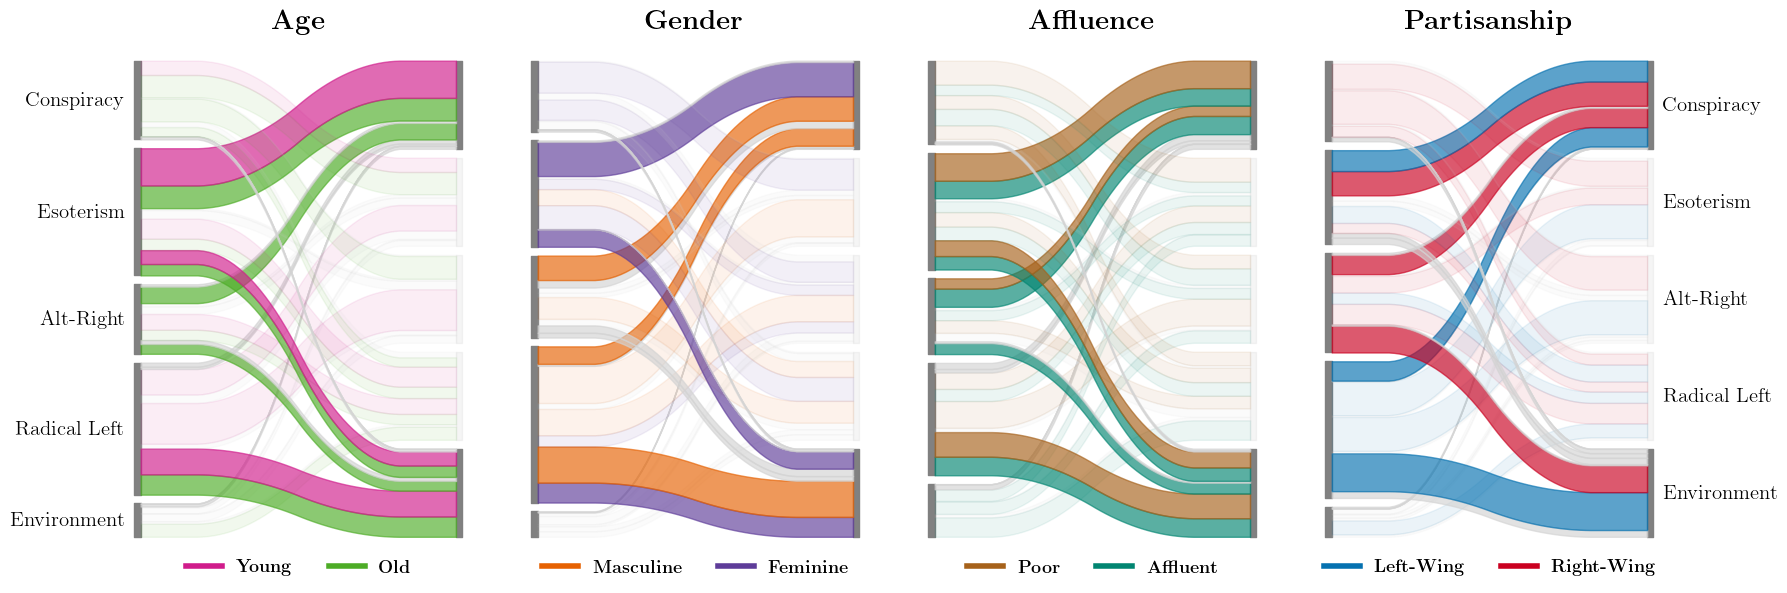

In [30]:
#We create the left and right arrays for the sankey diagram
#The (target, source) pairs are the keys of the sankey_data_age dictionary 
#Entries should be sorted by weight in descending order for each target

sankey_data_age = generate_sankey_dict(gateway_info, "age", 0.2)
sankey_data_gender = generate_sankey_dict(gateway_info, "gender", 0.2)
sankey_data_affluence = generate_sankey_dict(gateway_info, "affluence", 0.2)
sankey_data_partisan = generate_sankey_dict(gateway_info, "partisan", 0.2)

left_age, right_age, weights_age = get_sankey_lists(sankey_data_age)
left_gender, right_gender, weights_gender = get_sankey_lists(sankey_data_gender)
left_affluence, right_affluence, weights_affluence = get_sankey_lists(sankey_data_affluence)
left_partisan, right_partisan, weights_partisan = get_sankey_lists(sankey_data_partisan)

fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=False, sharey=True)
sankey_v6(left=left_age,
          right=right_age,
          leftWeight=weights_age,
          rightWeight=weights_age,
          colorDict= {"Conspiracy":"gray",
                  "Esoterism":"gray",
                  "Alt-Right":"gray",
                  "Radical Left":"gray",
                  "Environment":"gray"},
        leftLabels=["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"][::-1],
        rightLabels=["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"][::-1],
        flowColorFunc=coloring_function,
        flowConditions=sankey_data_age,
        ax=axs[0],
        highlightRight=["Conspiracy", "Environment"]),

sankey_v6(left=left_gender,
          right=right_gender,
          leftWeight=weights_gender,
          rightWeight=weights_gender,
          colorDict= {"Conspiracy":"gray",
                  "Esoterism":"gray",
                  "Alt-Right":"gray",
                  "Radical Left":"gray",
                  "Environment":"gray"},
        leftLabels=["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"][::-1],
        rightLabels=["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"][::-1],
        flowColorFunc=coloring_function,
        flowConditions=sankey_data_gender,
        ax=axs[1],
        highlightRight=["Conspiracy", "Environment"])
sankey_v6(left=left_affluence,
          right=right_affluence,
          leftWeight=weights_affluence,
          rightWeight=weights_affluence,
          colorDict= {"Conspiracy":"gray",
                  "Esoterism":"gray",
                  "Alt-Right":"gray",
                  "Radical Left":"gray",
                  "Environment":"gray"},
        leftLabels=["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"][::-1],
        rightLabels=["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"][::-1],
        flowColorFunc=coloring_function,
        flowConditions=sankey_data_affluence,
        ax=axs[2],
        highlightRight=["Conspiracy", "Environment"])
sankey_v6(left=left_partisan,
          right=right_partisan,
          leftWeight=weights_partisan,
          rightWeight=weights_partisan,
          colorDict= {"Conspiracy":"gray",
                  "Esoterism":"gray",
                  "Alt-Right":"gray",
                  "Radical Left":"gray",
                  "Environment":"gray"},
        leftLabels=["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"][::-1],
        rightLabels=["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"][::-1],
        flowColorFunc=coloring_function,
        flowConditions=sankey_data_partisan,
        ax=axs[3],
        highlightRight=["Conspiracy", "Environment"])

#We hide the labels on the right side of the left plots
for ax in [axs[0], axs[1], axs[2]]:
    for text in ax.texts:
        if text.get_position()[0] > 0:  # left nodes have x < 0
            text.set_visible(False)

#We hide the labels on the right side of the left plots
for ax in [axs[1], axs[2], axs[3]]:
    for text in ax.texts:
        if text.get_position()[0] < 0:  # left nodes have x < 0
            text.set_visible(False)

#Add titles to each subplot
axs[0].set_title(r"\textbf{Age}", fontsize=20)
axs[1].set_title(r"\textbf{Gender}", fontsize=20)
axs[2].set_title(r"\textbf{Affluence}", fontsize=20)
axs[3].set_title(r"\textbf{Partisanship}", fontsize=20)

#We add legends with the color codes exactly below and and to the center of the sankey
age_legend_elements = [plt.Line2D([0], [0], color="#d01c8b", lw=4, label=r'\textbf{Young}'),
                       plt.Line2D([0], [0], color="#4dac26", lw=4, label=r'\textbf{Old}')
                       ]

gender_legend_elements = [plt.Line2D([0], [0], color="#e66101", lw=4, label=r'\textbf{Masculine}'),
                          plt.Line2D([0], [0], color="#5e3c99", lw=4, label=r'\textbf{Feminine}')]
affluence_legend_elements = [plt.Line2D([0], [0], color="#a6611a", lw=4, label=r'\textbf{Poor}'),
                             plt.Line2D([0], [0], color="#018571", lw=4, label=r'\textbf{Affluent}')
                             ]
partisan_legend_elements = [plt.Line2D([0], [0], color="#0571b0", lw=4, label=r'\textbf{Left-Wing}'),
                            plt.Line2D([0], [0], color="#ca0020", lw=4, label=r'\textbf{Right-Wing}')]
axs[0].legend(handles=age_legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.06), fontsize=13, frameon=False, ncol=3)
axs[1].legend(handles=gender_legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.06), fontsize=13, frameon=False, ncol=3)
axs[2].legend(handles=affluence_legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.06), fontsize=13, frameon=False, ncol=3)
axs[3].legend(handles=partisan_legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.06), fontsize=13, frameon=False, ncol=3)

#We augment the font of the node labels
for ax in axs:
    for text in ax.texts:
        text.set_fontsize(15)

#We add a y axis label to the left of the entire figure
plt.tight_layout()
#plt.savefig(figures_path + "sankey_demographics_horizontal.pdf", format="pdf", dpi=300)
plt.show()

----

### **Figure S7: Differences in bridge and gateway rankings across sociodemographics**

In [31]:
def weighted_tau(ranking_A: list, ranking_B: list) -> float:
    """
    Calculate the weighted Kendall Tau correlation coefficient between two rankings.

    Parameters:
        ranking_A (list): The first ranking as a list of tuples (item, score).
        ranking_B (list): The second ranking as a list of tuples (item, score).

    Returns:
        float: The weighted Kendall Tau correlation coefficient.
    """
    # Convert to dictionaries for easy lookup
    dict_A = dict(ranking_A)
    dict_B = dict(ranking_B)

    # Ensure the items are in the same order
    ordered_items = sorted(dict_A.keys()) 
    # Extract scores in the same order for both rankings
    scores_A = [dict_A[item] for item in ordered_items]
    scores_B = [dict_B[item] for item in ordered_items]

    # Calculate the Kendall Tau
    stat, _ = stats.weightedtau(scores_A, scores_B)
    return stat

def kendall_tau(data: dict, bridges:bool=True)-> Tuple[list, list, list]:
    """
    Calculate the weighted Kendall Tau correlation coefficients for positive, negative, and combined reachability between communities.

    Parameters:
        data (dict): A dictionary containing the rankings for each community.
        bridges (bool): A flag indicating whether to calculate for bridges or gateways.

    Returns:
        Tuple[list, list, list]: The correlation coefficients for positive, negative, and combined reachability.
    """
    categories = [
        "age", "conspiracy", "spirituality", "Conservative", "socialism", "environment",
        "gender", "conspiracy", "spirituality", "Conservative", "socialism", "environment",
        "affluence", "conspiracy", "spirituality", "Conservative", "socialism", "environment",
        "partisan", "conspiracy", "spirituality", "Conservative", "socialism", "environment"]
    measurement = "bridges" if bridges else "gateways"
    positive, negative, combined = [], [], []
    for i in range(0, len(categories), 6):
        pos, neg, comb = [], [], []
        for j in range(1, 6):
            ranking_A = data[categories[j]]["none"]["none"][measurement]
            ranking_B_positive = data[categories[j]][categories[i]]["positive"][measurement]
            pos.append(weighted_tau(ranking_A, ranking_B_positive))
            ranking_B_negative = data[categories[j]][categories[i]]["negative"][measurement]
            neg.append((weighted_tau(ranking_A, ranking_B_negative)))
            comb.append((weighted_tau(ranking_B_positive, ranking_B_negative)))
        positive.append(pos)
        negative.append(neg)
        combined.append(comb)
    return positive, negative, combined

#Upload the gateway data
gateway_info = json.load(open(data_path + 'gateways_bridges_results_full_inverted_final.json'))
positive_kt_bridges, negative_kt_bridges, combined_kt_bridges = kendall_tau(gateway_info, True)
positive_kt_gateways, negative_kt_gateways, combined_kt_gateways = kendall_tau(gateway_info, False)

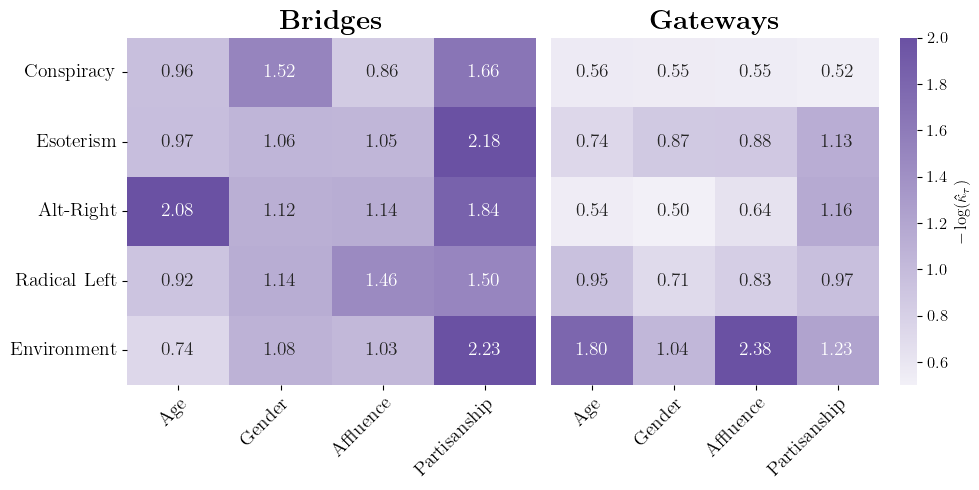

In [32]:
#Now we plot a heatmap of the results. We add a sequential colormap and the values of the heatmap in the cells
custom_cmap = LinearSegmentedColormap.from_list("custom_blues", ["#f2f0f7", "#6a51a3"])
# Combine the positive and negative Kendall Tau values. First for bridges and then for gateways
combined_kt_bridges_ = (-1)*np.log(np.array(combined_kt_bridges)).T
combined_kt_gateways_ = (-1)*np.log(np.array(combined_kt_gateways)).T
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
sns.heatmap(combined_kt_bridges_, cmap=custom_cmap, annot=True, fmt=".2f", vmin=0.5, vmax=2, annot_kws={"fontsize": 14}, cbar=False, ax=ax[0])
sns.heatmap(combined_kt_gateways_, cmap=custom_cmap, annot=True, fmt=".2f", vmin=0.5, vmax=2, annot_kws={"fontsize": 14}, cbar_kws={"label": r"$\mathbf{-\log(\hat{\kappa}_{\tau})}$"}, ax=ax[1])
#Here we set the names of the ticks
ax[0].set_yticks(ticks=[0.5, 1.5, 2.5, 3.5, 4.5], labels=["Conspiracy", "Esoterism", "Alt-Right", "Radical Left", "Environment"], rotation=0, fontsize=14)
ax[0].set_xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=["Age", "Gender", "Affluence", "Partisanship"], rotation=45, fontsize=14, ha="right", rotation_mode="anchor")
ax[1].set_xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=["Age", "Gender", "Affluence", "Partisanship"], rotation=45, fontsize=14, ha="right", rotation_mode="anchor")
#We take out the y tick lines for the second plot
for tick in ax[1].yaxis.get_ticklines():
    tick.set_visible(False)
ax[0].set_title(r"\textbf{Bridges}", fontsize=20)
ax[1].set_title(r"\textbf{Gateways}", fontsize=20)
plt.tight_layout()
#plt.savefig(figures_path + "kendall_tau_heatmap.pdf", format="pdf", dpi=300)
plt.show()

----

### **Figure 4: Differences in bridge and gateway rankings for conspiracy and environment communities**

In [35]:
def normalize_alpha(values:np.ndarray, min_alpha:float=0.5, max_alpha:float=0.9)-> np.ndarray:
    """
    Normalize the alpha values for plotting based on the input values.

    Parameters:
        values (np.ndarray): The input values to normalize.
        min_alpha (float): The minimum alpha value. Default is 0.5.
        max_alpha (float): The maximum alpha value. Default is 0.9.

    Returns:
        np.ndarray: The normalized alpha values.
    """
    vmin, vmax = values.min(), values.max()
    if vmax == vmin:
        return np.full_like(values, max_alpha, dtype=float)
    return min_alpha + (values - vmin) / (vmax - vmin) * (max_alpha - min_alpha)

def plot_kt_bars(ax:plt.Axes, full_array:np.ndarray, normalize_values:bool=True, legend:bool=True, title:str="Bridges")-> plt.Axes:
    """
    Plot horizontal bar charts for the weighted Kendall Tau correlation coefficients.

    Parameters:
        ax (plt.Axes): The matplotlib axes to plot on.
        full_array (np.ndarray): A 2D array containing the values to plot.
        normalize_values (bool): Whether to normalize the alpha values based on the input values. Default is True.
        legend (bool): Whether to display the legend. Default is True.
        title (str): The title of the plot. Default is "Bridges".

    Returns:
        plt.Axes: The matplotlib axes with the plotted bar charts.
    """
    #Column and row labels
    col_labels = ["Age", "Gender", "Affluence", "Partisanship"]
    
    #Arrays of interest
    array1 = full_array[-1] #Environment
    array2 = full_array[0] #Conspiracy

    #Parameters for plotting
    y = np.arange(len(array1))[::-1]  #positions for bars
    bar_height = 0.2  #thickness of each bar
    inner_gap = 0.01 #gap between the two bars of the same category
    #Transparency based on values (optional)
    alpha1 = normalize_alpha(array1) if normalize_values else np.full_like(array1, 0.8)
    alpha2 = normalize_alpha(array2) if normalize_values else np.full_like(array2, 0.8)

    #Plot bars one by one to control individual alpha
    for i in range(len(array1)):
        ax.barh(y[i] - bar_height/2-inner_gap/2, array1[i],
                height=bar_height,
                color='#1b9e77',
                alpha=alpha1[i])
        
        ax.barh(y[i] + bar_height/2+inner_gap/2, array2[i],
                height=bar_height,
                color='#7570b3',
                alpha=alpha2[i])
    #Plot parameter lines and labels
    ax.set_yticks(y)
    ax.set_yticklabels(col_labels, fontsize=14)
    ax.set_xlabel(r"$\mathbf{-\log(\hat{\kappa}_{\tau})}$", fontsize=15)
    ax.set_title(r'\textbf{' + title + '}', fontsize=18)

    if legend:
        legend_elements = [plt.Line2D([0], [0], color="#7570b3", lw=4, label=r'Conspiracy'),
                        plt.Line2D([0], [0], color="#1b9e77", lw=4, label=r'Environment')]
        ax.legend(handles=legend_elements, loc='center right', fontsize=12, frameon=False, ncol=1)

    return ax

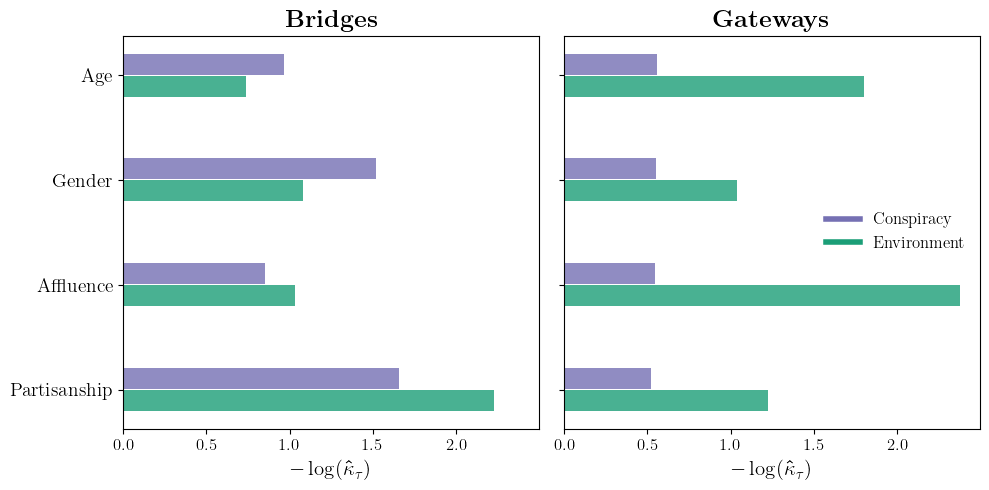

In [ ]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10, 5), sharey=True, sharex=True)

plot_kt_bars(ax1, combined_kt_bridges_, normalize_values=False, legend=False, title="Bridges")
plot_kt_bars(ax2, combined_kt_gateways_, normalize_values=False, legend=True, title="Gateways")
plt.tight_layout()
#plt.savefig(figures_path + "kendall_tau_conspiracy_environment_bars.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()

----

### **Figure S8: Most shared domains across sociodemographic groups.**

In [94]:
def plot_mirrored_frequencies(ax: plt.Axes, ranking1_tau: list, ranking2_tau: list, days: list,
                          left_legends: list, right_legends: list, day_colors: list,
                          left_bar_labels: list, right_bar_labels: list,
                          bar_height: float = 0.6, spacing: float = 1.5, step: float = 0.6):
    """
    Plots a mirrored horizontal bar chart comparing two rankings over multiple days.

    Parameters:
    - ax: matplotlib Axes
    - ranking1_tau: list of lists of negative values (per day, per bar)
    - ranking2_tau: list of lists of positive values (per day, per bar)
    - days: list of day labels
    - left_legends, right_legends: list of strings (1 per day)
    - day_colors: list of (left_color, right_color) tuples (1 per day)
    - left_bar_labels, right_bar_labels: list of lists of strings (1 list per day, 1 string per bar)
    - bar_height: float, height of each bar
    - spacing: float, vertical space between different days
    - step: float, vertical distance between bars within the same day
    """
    bar_ys = []
    ranking1_divs = []
    ranking2_divs = []
    ranking1_colors = []
    ranking2_colors = []
    left_labels = []
    right_labels = []

    y_positions = []
    ytick_labels = []

    cur_y = 0
    for day_idx, (day, tau1_row, tau2_row, left_labels_day, right_labels_day) in enumerate(
        zip(days, ranking1_tau, ranking2_tau, left_bar_labels, right_bar_labels)
    ):
        left_color, right_color = day_colors[day_idx]

        # Add day label at the top
        y_positions.append(cur_y)
        ytick_labels.append(f'$\\textbf{{{day}}}$')

        # Sort by magnitude descending
        sorted_data = sorted(zip(tau1_row, tau2_row, left_labels_day, right_labels_day),
                             key=lambda x: max(abs(x[0]), abs(x[1])), reverse=True)

        for i, (tau1, tau2, l_label, r_label) in enumerate(sorted_data):
            y = cur_y + i * step
            bar_ys.append(y)
            ranking1_divs.append(tau1)
            ranking2_divs.append(tau2)
            ranking1_colors.append(left_color)
            ranking2_colors.append(right_color)
            left_labels.append(l_label)
            right_labels.append(r_label)

        cur_y += len(tau1_row) * step + spacing

    # Plot bars
    bars1 = ax.barh(bar_ys, ranking1_divs, height=bar_height, color=ranking1_colors)
    bars2 = ax.barh(bar_ys, ranking2_divs, height=bar_height, color=ranking2_colors)

    # Add labels next to bars
    label_padding = 0.1
    for bar, label in zip(bars1, left_labels):
        x = bar.get_x() + bar.get_width() - label_padding
        ax.text(x, bar.get_y() + bar.get_height() / 2,
                label, va='center', ha='right', fontsize=7)

    for bar, label in zip(bars2, right_labels):
        x = bar.get_x() + bar.get_width() + label_padding
        ax.text(x, bar.get_y() + bar.get_height() / 2,
                label, va='center', ha='left', fontsize=7)

    # Y-axis setup
    ax.set_yticks(y_positions)
    ax.set_yticklabels(ytick_labels, fontsize=14)
    ax.invert_yaxis()

    # Remove tick marks
    for tick in ax.yaxis.get_major_ticks():
        tick.tick1line.set_markersize(0)
        tick.tick2line.set_markersize(0)

    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlim(-8.5, 8.5)

    # Group-level legends ABOVE each group
    n_exp_per_day = [len(t) for t in ranking1_tau]
    cur_y = 0
    for day_idx, n_exp in enumerate(n_exp_per_day):
        y_top = cur_y - step / 2  # slightly above the first bar of the group
        left_color, right_color = day_colors[day_idx]

        ax.text(-10.5, y_top-0.08, left_legends[day_idx], va='bottom', ha='left', fontsize=11, color=left_color)
        ax.text(10.5, y_top-0.08, right_legends[day_idx], va='bottom', ha='right', fontsize=11, color=right_color)

        cur_y += n_exp * step + spacing

def get_frequency_dict(records: list, dimension: str, k: int = 10, filter: bool = False)-> Tuple[list, list]:
    """
    Generate a weighted frequency dictionary for a given dimension and return the top and bottom k URLs.

    Parameters:
        records (list): A list of records, where each record is a dictionary containing the dimension and associated domains with frequencies.
        dimension (str): The dimension to consider (e.g., "age", "gender").
        k (int): The number of top and bottom URLs to return.
        filter (bool): Whether to filter out outliers based on the 25th and 75th percentiles.

    Returns:
        Tuple[list, list]: A tuple containing two lists: the top k URLs and the bottom k URLs.
    """
    # keep only records that actually have a value for this dimension
    valid = [r for r in records if dimension in r and pd.notna(r[dimension])]

    if filter:
        scores = pd.Series([r[dimension] for r in valid])
        q25, q75 = scores.quantile(0.25), scores.quantile(0.75)
        valid = [r for r in valid if r[dimension] < q25 or r[dimension] > q75]

    # build the weighted frequency dict
    weighted_url_counts = {}
    for record in valid:
        score = record[dimension]
        for url, freq in record['domains']:
            weighted_url_counts[url] = weighted_url_counts.get(url, 0) + freq * score

    # sort and get top/bottom k
    sorted_urls = sorted(weighted_url_counts.items(), key=lambda x: x[1], reverse=True)
    top_k_urls = sorted_urls[:k]
    bottom_k_urls = sorted_urls[-k:][::-1]

    return top_k_urls, bottom_k_urls



In [84]:
#Open the merged data json file
with open(data_path + "merged_user_domains_with_scores.json", "r") as f:
    merged_user_domains_with_scores = json.load(f)

In [95]:
##Filter the url counts before entering Conspiracy
url_counts_conspiracy_age_pos, url_counts_conspiracy_age_neg = get_frequency_dict(merged_user_domains_with_scores["conspiracy"], "age", k=5, filter=True)
url_counts_conspiracy_gender_pos, url_counts_conspiracy_gender_neg = get_frequency_dict(merged_user_domains_with_scores["conspiracy"], "gender", k=5, filter=True)
url_counts_conspiracy_partisanship_pos, url_counts_conspiracy_partisanship_neg = get_frequency_dict(merged_user_domains_with_scores["conspiracy"], "partisanship", k=5, filter=True)
url_counts_conspiracy_affluence_pos, url_counts_conspiracy_affluence_neg = get_frequency_dict(merged_user_domains_with_scores["conspiracy"], "affluence", k=5, filter=True)

#We create the rankings for the left and right bars of the mirrored bar chart. We use the negative log of the values to make them more comparable across different dimensions.  
#We multiply the negative values by -1 to make them positive, and then take the log of the positive values.
ranking_conspiracy_left = [(-1)*np.log((-1)*np.array([v for k,v in url_counts_conspiracy_age_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_conspiracy_gender_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_conspiracy_affluence_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_conspiracy_partisanship_neg]))]
ranking_conspiracy_right = [np.log(np.array([v for k,v in url_counts_conspiracy_age_pos])),
                np.log(np.array([v for k,v in url_counts_conspiracy_gender_pos])),
                np.log(np.array([v for k,v in url_counts_conspiracy_affluence_pos])),
                np.log(np.array([v for k,v in url_counts_conspiracy_partisanship_pos]))]


#We create the labels for the left and right bars of the mirrored bar chart. 
left_bar_labels_conspiracy = [[k for k,v in url_counts_conspiracy_age_neg],
                     [k for k,v in url_counts_conspiracy_gender_neg],
                     [k for k,v in url_counts_conspiracy_affluence_neg],
                     [k for k,v in url_counts_conspiracy_partisanship_neg]]
right_bar_labels_conspiracy = [[k for k,v in url_counts_conspiracy_age_pos],
                     [k for k,v in url_counts_conspiracy_gender_pos],
                     [k for k,v in url_counts_conspiracy_affluence_pos],
                     [k for k,v in url_counts_conspiracy_partisanship_pos]]

##Filter the url counts before entering Conservative
url_counts_conservative_age_pos, url_counts_conservative_age_neg = get_frequency_dict(merged_user_domains_with_scores["conservative"], "age", k=5, filter=True)
url_counts_conservative_gender_pos, url_counts_conservative_gender_neg = get_frequency_dict(merged_user_domains_with_scores["conservative"], "gender", k=5, filter=True)
url_counts_conservative_partisanship_pos, url_counts_conservative_partisanship_neg = get_frequency_dict(merged_user_domains_with_scores["conservative"], "partisanship", k=5, filter=True)
url_counts_conservative_affluence_pos, url_counts_conservative_affluence_neg = get_frequency_dict(merged_user_domains_with_scores["conservative"], "affluence", k=5, filter=True)

ranking_conservative_left = [(-1)*np.log((-1)*np.array([v for k,v in url_counts_conservative_age_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_conservative_gender_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_conservative_affluence_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_conservative_partisanship_neg]))]
ranking_conservative_right = [np.log(np.array([v for k,v in url_counts_conservative_age_pos])),
                np.log(np.array([v for k,v in url_counts_conservative_gender_pos])),
                np.log(np.array([v for k,v in url_counts_conservative_affluence_pos])),
                np.log(np.array([v for k,v in url_counts_conservative_partisanship_pos]))]


#Labels bars
left_bar_labels_conservative = [[k for k,v in url_counts_conservative_age_neg],
                     [k for k,v in url_counts_conservative_gender_neg],
                     [k for k,v in url_counts_conservative_affluence_neg],
                     [k for k,v in url_counts_conservative_partisanship_neg]]
right_bar_labels_conservative = [[k for k,v in url_counts_conservative_age_pos],
                     [k for k,v in url_counts_conservative_gender_pos],
                     [k for k,v in url_counts_conservative_affluence_pos],
                     [k for k,v in url_counts_conservative_partisanship_pos]]

## Filter the url counts before entering Environment
url_counts_environment_age_pos, url_counts_environment_age_neg = get_frequency_dict(merged_user_domains_with_scores["environment"], "age", k=5, filter=True)
url_counts_environment_gender_pos, url_counts_environment_gender_neg = get_frequency_dict(merged_user_domains_with_scores["environment"], "gender", k=5, filter=True)
url_counts_environment_partisanship_pos, url_counts_environment_partisanship_neg = get_frequency_dict(merged_user_domains_with_scores["environment"], "partisanship", k=5, filter=True)
url_counts_environment_affluence_pos, url_counts_environment_affluence_neg = get_frequency_dict(merged_user_domains_with_scores["environment"], "affluence", k=5, filter=True)

ranking_environment_left = [(-1)*np.log((-1)*np.array([v for k,v in url_counts_environment_age_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_environment_gender_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_environment_affluence_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_environment_partisanship_neg]))]
ranking_environment_right = [np.log(np.array([v for k,v in url_counts_environment_age_pos])),
                np.log(np.array([v for k,v in url_counts_environment_gender_pos])),
                np.log(np.array([v for k,v in url_counts_environment_affluence_pos])),
                np.log(np.array([v for k,v in url_counts_environment_partisanship_pos]))]


#Labels bars
left_bar_labels_environment = [[k for k,v in url_counts_environment_age_neg],
                     [k for k,v in url_counts_environment_gender_neg],
                     [k for k,v in url_counts_environment_affluence_neg],
                     [k for k,v in url_counts_environment_partisanship_neg]]
right_bar_labels_environment = [[k for k,v in url_counts_environment_age_pos],
                     [k for k,v in url_counts_environment_gender_pos],
                     [k for k,v in url_counts_environment_affluence_pos],
                     [k for k,v in url_counts_environment_partisanship_pos]]    

##Filter the url counts before entering Socialism
url_counts_socialism_age_pos, url_counts_socialism_age_neg = get_frequency_dict(merged_user_domains_with_scores["socialism"], "age", k=5, filter=True)
url_counts_socialism_gender_pos, url_counts_socialism_gender_neg = get_frequency_dict(merged_user_domains_with_scores["socialism"], "gender", k=5, filter=True)
url_counts_socialism_partisanship_pos, url_counts_socialism_partisanship_neg = get_frequency_dict(merged_user_domains_with_scores["socialism"], "partisanship", k=5, filter=True)
url_counts_socialism_affluence_pos, url_counts_socialism_affluence_neg = get_frequency_dict(merged_user_domains_with_scores["socialism"], "affluence", k=5, filter=True)

ranking_socialism_left = [(-1)*np.log((-1)*np.array([v for k,v in url_counts_socialism_age_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_socialism_gender_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_socialism_affluence_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_socialism_partisanship_neg]))]
ranking_socialism_right = [np.log(np.array([v for k,v in url_counts_socialism_age_pos])),
                np.log(np.array([v for k,v in url_counts_socialism_gender_pos])),
                np.log(np.array([v for k,v in url_counts_socialism_affluence_pos])),
                np.log(np.array([v for k,v in url_counts_socialism_partisanship_pos]))]


#Labels bars
left_bar_labels_socialism = [[k for k,v in url_counts_socialism_age_neg],
                     [k for k,v in url_counts_socialism_gender_neg],
                     [k for k,v in url_counts_socialism_affluence_neg],
                     [k for k,v in url_counts_socialism_partisanship_neg]]
right_bar_labels_socialism = [[k for k,v in url_counts_socialism_age_pos],
                     [k for k,v in url_counts_socialism_gender_pos],
                     [k for k,v in url_counts_socialism_affluence_pos],
                     [k for k,v in url_counts_socialism_partisanship_pos]]

##Filter the url counts before entering Spirituality
url_counts_spirituality_age_pos, url_counts_spirituality_age_neg = get_frequency_dict(merged_user_domains_with_scores["spirituality"], "age", k=5, filter=True)
url_counts_spirituality_gender_pos, url_counts_spirituality_gender_neg = get_frequency_dict(merged_user_domains_with_scores["spirituality"], "gender", k=5, filter=True)
url_counts_spirituality_partisanship_pos, url_counts_spirituality_partisanship_neg = get_frequency_dict(merged_user_domains_with_scores["spirituality"], "partisanship", k=5, filter=True)
url_counts_spirituality_affluence_pos, url_counts_spirituality_affluence_neg = get_frequency_dict(merged_user_domains_with_scores["spirituality"], "affluence", k=5, filter=True)
ranking_spirituality_left = [(-1)*np.log((-1)*np.array([v for k,v in url_counts_spirituality_age_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_spirituality_gender_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_spirituality_affluence_neg])),
                (-1)*np.log((-1)*np.array([v for k,v in url_counts_spirituality_partisanship_neg]))]
ranking_spirituality_right = [np.log(np.array([v for k,v in url_counts_spirituality_age_pos])),
                np.log(np.array([v for k,v in url_counts_spirituality_gender_pos])),
                np.log(np.array([v for k,v in url_counts_spirituality_affluence_pos])),
                np.log(np.array([v for k,v in url_counts_spirituality_partisanship_pos]))]
#Labels bars
left_bar_labels_spirituality = [[k for k,v in url_counts_spirituality_age_neg],
                     [k for k,v in url_counts_spirituality_gender_neg],
                     [k for k,v in url_counts_spirituality_affluence_neg],
                     [k for k,v in url_counts_spirituality_partisanship_neg]]
right_bar_labels_spirituality = [[k for k,v in url_counts_spirituality_age_pos],
                     [k for k,v in url_counts_spirituality_gender_pos],
                     [k for k,v in url_counts_spirituality_affluence_pos],
                     [k for k,v in url_counts_spirituality_partisanship_pos]]



/var/folders/jb/blc95kfn77qcc1pqkvjw7y_c0000gn/T/ipykernel_29935/4197515527.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("figures_pdf/url_frequencies_weighted_filtered.pdf", format="pdf", dpi=300, bbox_inches='tight')
/Users/sanchez_miguel/miniconda3/envs/reddit-dems/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


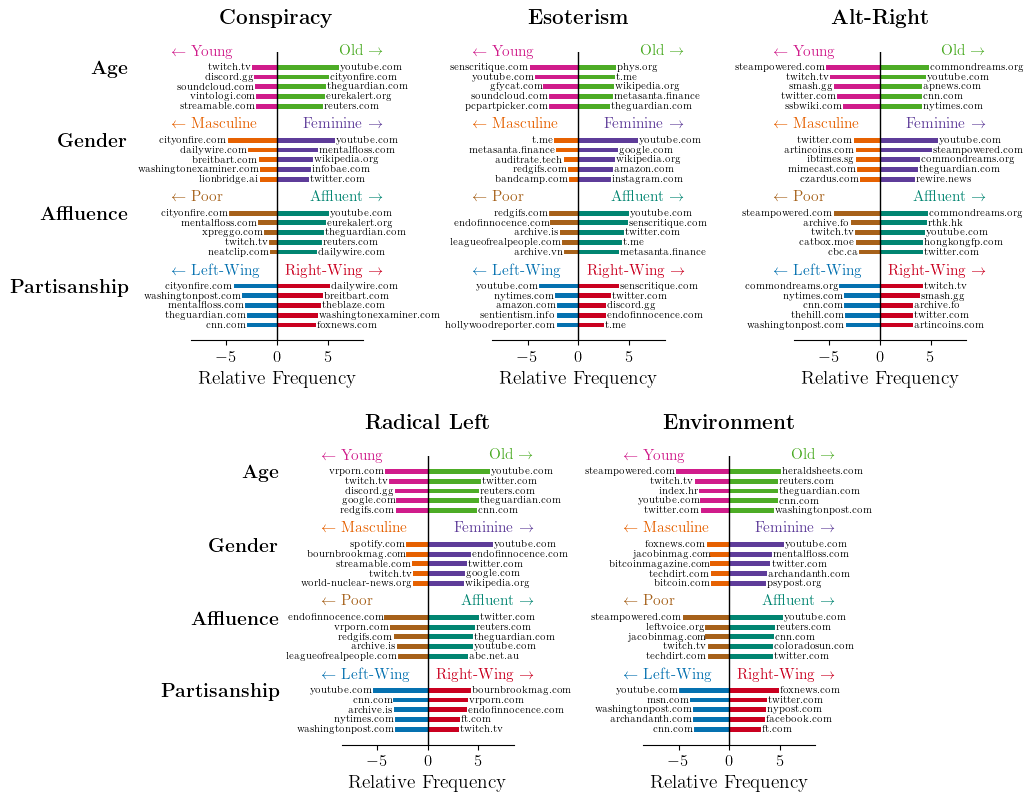

In [99]:
#We plot the url frequencies
fig = plt.figure(figsize=(10, 9),tight_layout=True)
spec = gridspec.GridSpec(ncols=6, nrows=2, figure=fig, wspace=6, hspace=0.4)
# Row 0: 3 plots, each 2 columns wide
ax1 = fig.add_subplot(spec[0, 0:2])
ax2 = fig.add_subplot(spec[0, 2:4])
ax3 = fig.add_subplot(spec[0, 4:6])
# Row 1: 2 plots, also 2 columns wide, centered
ax4 = fig.add_subplot(spec[1, 1:3])
ax5 = fig.add_subplot(spec[1, 3:5])
axs = [ax1, ax2, ax3, ax4, ax5]


days = ['Age', 'Gender', 'Affluence', 'Partisanship']
left_legends = [
    r"$\leftarrow$ Young",
    r"$\leftarrow$ Masculine",
    r"$\leftarrow$ Poor",
    r"$\leftarrow$ Left-Wing",
]

right_legends = [
    r"Old $\rightarrow$",
     r"Feminine $\rightarrow$",
    r"Affluent $\rightarrow$",
    r"Right-Wing $\rightarrow$"
]

day_colors = [('#d01c8b', '#4dac26'), ('#e66101','#5e3c99'), ('#a6611a', '#018571'), ('#0571b0','#ca0020')]


plot_mirrored_frequencies(axs[0], ranking_conspiracy_left, ranking_conspiracy_right, days,
                      left_legends, right_legends, day_colors,
                      left_bar_labels_conspiracy, right_bar_labels_conspiracy,
                      bar_height=0.1, spacing=0.5, step=0.2)
#We set the title of the first plot
axs[0].set_title(r"$\textbf{Conspiracy}$", fontsize=15, fontweight='bold', pad=20)

plot_mirrored_frequencies(axs[1], ranking_spirituality_left, ranking_spirituality_right, days,
                      left_legends, right_legends, day_colors,
                      left_bar_labels_spirituality, right_bar_labels_spirituality,
                      bar_height=0.1, spacing=0.5, step=0.2)
axs[1].set_title(r"$\textbf{Esoterism}$", fontsize=15, fontweight='bold', pad=20)
plot_mirrored_frequencies(axs[2], ranking_conservative_left, ranking_conservative_right, days,
                      left_legends, right_legends, day_colors,
                      left_bar_labels_conservative, right_bar_labels_conservative,
                      bar_height=0.1, spacing=0.5, step=0.2)
axs[2].set_title(r"$\textbf{Alt-Right}$", fontsize=15, fontweight='bold', pad=20)
plot_mirrored_frequencies(axs[3], ranking_socialism_left, ranking_socialism_right, days,
                      left_legends, right_legends, day_colors,
                      left_bar_labels_socialism, right_bar_labels_socialism,
                      bar_height=0.1, spacing=0.5, step=0.2)
axs[3].set_title(r"$\textbf{Radical Left}$", fontsize=15, fontweight='bold', pad=20)

plot_mirrored_frequencies(axs[4], ranking_environment_left, ranking_environment_right, days,
                      left_legends, right_legends, day_colors,
                      left_bar_labels_environment, right_bar_labels_environment,
                      bar_height=0.1, spacing=0.5, step=0.2)
axs[4].set_title(r"$\textbf{Environment}$", fontsize=15, fontweight='bold', pad=20)

#We mantain only the xaxis line and take out the box
for i, ax in enumerate(axs):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    #Add x axis label
    ax.set_xlabel(r'Relative Frequency', fontsize=14)
    #If it is not the 0 or 3 plot, we remove the y axis labels
    if i not in [0, 3]:
        ax.set_yticks([])
    else:
        ax.yaxis.set_tick_params(pad=45)
        #We make the tick lines non visible
        ax.tick_params(axis='y', which='both', length=0)
plt.savefig("figures_pdf/url_frequencies_weighted_filtered.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()


----

### **Figure 5: Most shared URL domains prior to entry into conspiratorial and environmental communities.**

/var/folders/jb/blc95kfn77qcc1pqkvjw7y_c0000gn/T/ipykernel_29935/2197498639.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(
/Users/sanchez_miguel/miniconda3/envs/reddit-dems/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


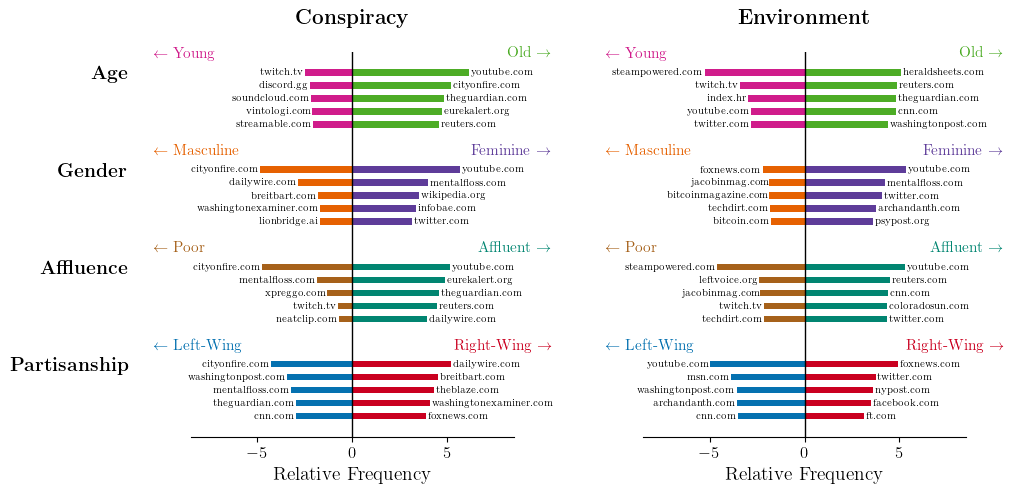

In [100]:
#We plot only the conspiracy and environment plots in a mirrored bar chart
fig = plt.figure(figsize=(10, 5), tight_layout=True)
spec = gridspec.GridSpec(ncols=2, nrows=1, figure=fig, wspace=0.4)

ax1 = fig.add_subplot(spec[0, 0])
ax2 = fig.add_subplot(spec[0, 1])

axs = [ax1, ax2]

days = ['Age', 'Gender', 'Affluence', 'Partisanship']

left_legends = [
    r"$\leftarrow$ Young",
    r"$\leftarrow$ Masculine",
    r"$\leftarrow$ Poor",
    r"$\leftarrow$ Left-Wing",
]

right_legends = [
    r"Old $\rightarrow$",
    r"Feminine $\rightarrow$",
    r"Affluent $\rightarrow$",
    r"Right-Wing $\rightarrow$"
]

day_colors = [
    ('#d01c8b', '#4dac26'),
    ('#e66101','#5e3c99'),
    ('#a6611a', '#018571'),
    ('#0571b0','#ca0020')
]

# ---- Conspiracy ----
plot_mirrored_frequencies(
    ax1,
    ranking_conspiracy_left,
    ranking_conspiracy_right,
    days,
    left_legends,
    right_legends,
    day_colors,
    left_bar_labels_conspiracy,
    right_bar_labels_conspiracy,
    bar_height=0.1,
    spacing=0.5,
    step=0.2
)

ax1.set_title(r"$\textbf{Conspiracy}$", fontsize=15, fontweight='bold', pad=20)

# ---- Environment ----
plot_mirrored_frequencies(
    ax2,
    ranking_environment_left,
    ranking_environment_right,
    days,
    left_legends,
    right_legends,
    day_colors,
    left_bar_labels_environment,
    right_bar_labels_environment,
    bar_height=0.1,
    spacing=0.5,
    step=0.2
)

ax2.set_title(r"$\textbf{Environment}$", fontsize=15, fontweight='bold', pad=20)

# ---- Clean axes styling ----
for i, ax in enumerate(axs):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    #Add x axis label
    ax.set_xlabel(r'Relative Frequency', fontsize=14)

    if i != 0:
        ax.set_yticks([])
    else:
        ax.yaxis.set_tick_params(pad=45)
        ax.tick_params(axis='y', which='both', length=0)

plt.savefig(
    "figures_pdf/url_frequencies_weighted_filtered_conspiracy.pdf",
    format="pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


----

### **Tables 1, S2-S11, : Most shared URL domains prior to entry into conspiratorial and environmental communities.**

In [108]:
N_MONTHS = 60
MIN_MONTHLY_USERS = 5
 
  
def build_subreddit_stats(sorted_subreddit_stats: dict, seed_communities: list[str], n_months: int = N_MONTHS) -> dict[str, float]:
    """
    Pad monthly counts to `n_months` with zeros, average them, and keep only subreddits that appear in `seed_communities`.

    Parameters:
        sorted_subreddit_stats (dict): A dictionary containing subreddit statistics, where keys are subreddit names and values are dictionaries with monthly counts.
        seed_communities (list[str]): A list of subreddit names to filter the statistics.
        n_months (int): The number of months to pad the monthly counts to. Default is 60.
    """
    seeds = set(seed_communities)
    stats = {}
    for subreddit, s in sorted_subreddit_stats.items():
        if subreddit not in seeds:
            continue
        counts = list(s["monthly_counts"])          # copy, don't mutate input
        counts += [0] * (n_months - len(counts))    # pad with zeros
        stats[subreddit] = np.average(counts)
    return stats
 
 
def get_items_df(results: dict, stats: dict[str, float], subreddit_type: str, axis: str, sign: str, item_type: str, min_users: float = MIN_MONTHLY_USERS) -> pd.DataFrame:
    """
    Return a dataframe of (subreddit, pagerank, average_monthly_users) for one combination of subreddit type / axis / sign / item type,
    filtered to subreddits with more than `min_users` average monthly users.

    Parameters:
        results (dict): A nested dictionary containing the results of subreddit analysis.
        stats (dict[str, float]): A dictionary mapping subreddit names to their average monthly user counts.
        subreddit_type (str): The type of subreddit (e.g., "conspiracy", "environment").
        axis (str): The axis of analysis (e.g., "age", "gender").
        sign (str): The sign of the analysis (e.g., "positive", "negative").
        item_type (str): The type of item to retrieve (e.g., "bridge", "gateway").
        min_users (float): The minimum average monthly users required for a subreddit to be included.
    """
    try:
        items = results[subreddit_type][axis][sign][item_type]
    except KeyError as e:
        raise KeyError(
            f"No entry for {subreddit_type}/{axis}/{sign}/{item_type}"
        ) from e
 
    df = pd.DataFrame(items, columns=["subreddit", "pagerank"])
    df["average_monthly_users"] = df["subreddit"].map(stats).fillna(0)
    return df[df["average_monthly_users"] > min_users].reset_index(drop=True)
 
 
def get_positive_negative(results: dict, stats: dict[str, float], subreddit_type: str, axis: str, item_type: str, min_users: float = MIN_MONTHLY_USERS):
    """
    Convenience wrapper returning (df_positive, df_negative).

    Parameters:
        results (dict): A nested dictionary containing the results of subreddit analysis.
        stats (dict[str, float]): A dictionary mapping subreddit names to their average monthly user counts.
        subreddit_type (str): The type of subreddit (e.g., "conspiracy", "environment").
        axis (str): The axis of analysis (e.g., "age", "gender").
        item_type (str): The type of item to retrieve (e.g., "bridge", "gateway").
        min_users (float): The minimum average monthly users required for a subreddit to be included.
    """
    df_pos = get_items_df(results, stats, subreddit_type, axis, "positive",
                          item_type, min_users)
    df_neg = get_items_df(results, stats, subreddit_type, axis, "negative",
                          item_type, min_users)
    return df_pos, df_neg

In [109]:
#We open the files containing the sorted subreddit stats and the gateways/bridges results
with open(supplementary_data_path+"sorted_subreddit_stats.json", "r") as f:
    sorted_subreddit_stats = json.load(f)

with open(data_path+"gateways_bridges_results_full_inverted_final.json", "r") as f:
    gateways_bridges_results = json.load(f)

#Now we read the seed_communities.csv with pandas
seed_communities_df = pd.read_csv(supplementary_data_path+"seed_communities.csv")
#We convert the id column to a list
seed_communities = seed_communities_df["id"].tolist()

In [179]:
stats = build_subreddit_stats(sorted_subreddit_stats, seed_communities)
 
# Single combination. We can try to build any table with each combination.
df_positive, df_negative = get_positive_negative(
    gateways_bridges_results, stats,
    subreddit_type="environment", axis="affluence", item_type="gateways")

print("---- Positive ---")
print(df_positive.head(10))
print("---- Negative ---")
print(df_negative.head(10))

---- Positive ---
         subreddit  pagerank  average_monthly_users
0      environment  0.000122              41.300000
1           energy  0.000095              11.883333
2        ZeroWaste  0.000076              45.700000
3         business  0.000076              23.000000
4        Economics  0.000067              19.283333
5          economy  0.000052              20.083333
6   sustainability  0.000047              13.233333
7          climate  0.000046              15.566667
8  RenewableEnergy  0.000025               5.516667
9    climatechange  0.000021              12.016667
---- Negative ---
             subreddit      pagerank  average_monthly_users
0              climate  1.704845e-05              15.566667
1        climatechange  1.631815e-05              12.016667
2     ClimateOffensive  1.394050e-05               6.100000
3  ExtinctionRebellion  7.079301e-06               6.300000
4              economy  3.682077e-06              20.083333
5    ClimateActionPlan  2.982585